In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

from agents.Classe_agent import Agent
from metrics import metrics_plot
from topologies.NetworkTopology import NetworkTopology

from models.model import Net,AlexNet

from training.plot_benchmark_results import plot_all_benchmark_metrics
from training.plot_benchmark_results import print_benchmark_summary

from metrics.metrics import plot_average_distance, node_weight_metric

from metrics.metrics import plot_cumulative_times ,plot_all_agent_node_weight_metric,plot_distance_heatmap,plot_cosine_similarity,plot_epoch_times

from metrics.Classe_model_metrics import ModelMetrics
#from metrics.plot_benchmark import*
from synchronize_weight import*
from training.scrpit_generate_agent import generate_agent
from training.scrpit_train_agent_sequential import benchmark_sequential
from hyperparametres import *
from ExperimentRunner import ExperimentRunner


In [2]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.version
torch.version.cuda
torch.cuda.is_available()

agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775


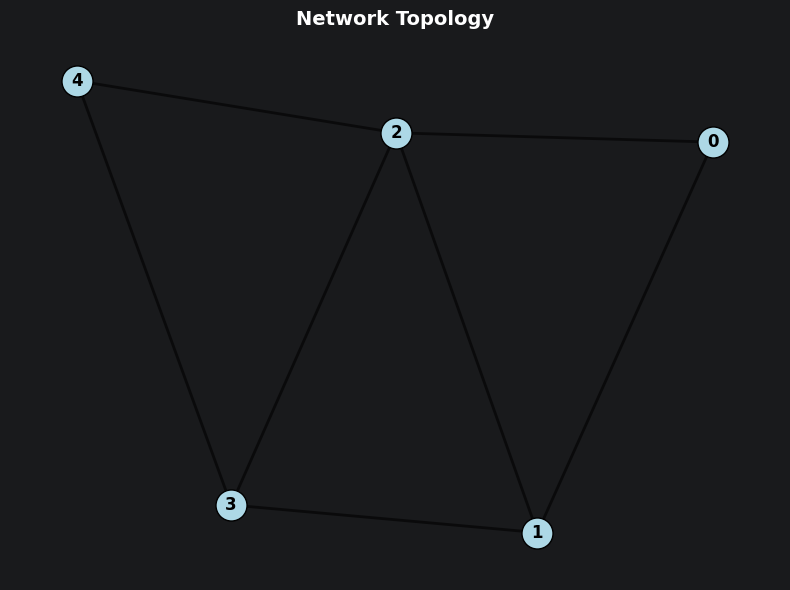

In [10]:
agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)

random_graph = NetworkTopology.random_graph(len(agent_list))

NetworkTopology.visualize_graph(random_graph)


  RUN — méthode : Average_consensus_fully_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 4 start
Agent 3 start
Agent 2 start
Agent 0 start
Agent 1 start
Model4 - Acc:14.4 % - Loss:2.2833959501981735 %
Model3 - Acc:14.44 % - Loss:2.279783539056778 %
Model0 - Acc:15.21 % - Loss:2.2701603037118914 %
Model1 - Acc:11.03 % - Loss:2.2990782907009124 %
Model2 - Acc:13.28 % - Loss:2.264205958843231 %
[DEBUG] set_epoch_messages called → 20 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 20
[DEBUG] _record epoch=0 → n_messages=20
  [Epoch 1/10] ✓  time=27.84s  cumulative=27.84s
  [Epoch 2/10] threads started …
Agent 3 start
Agent 2 start
Agent 1 start
Agent 4 start
Agent 0 start
Model3 - Acc:13.34 % - Loss:2.2971866986751555 %
Model2 - Acc:15.08 % - Loss:2.29580832862854 %
Model1 - Acc:13.18 % - Loss:2.296805119037628 %
Model4 - Acc:14.7 % - Loss:2.295214906215668 %
Model0 - Acc:11.79 % - Loss:2.2958432922

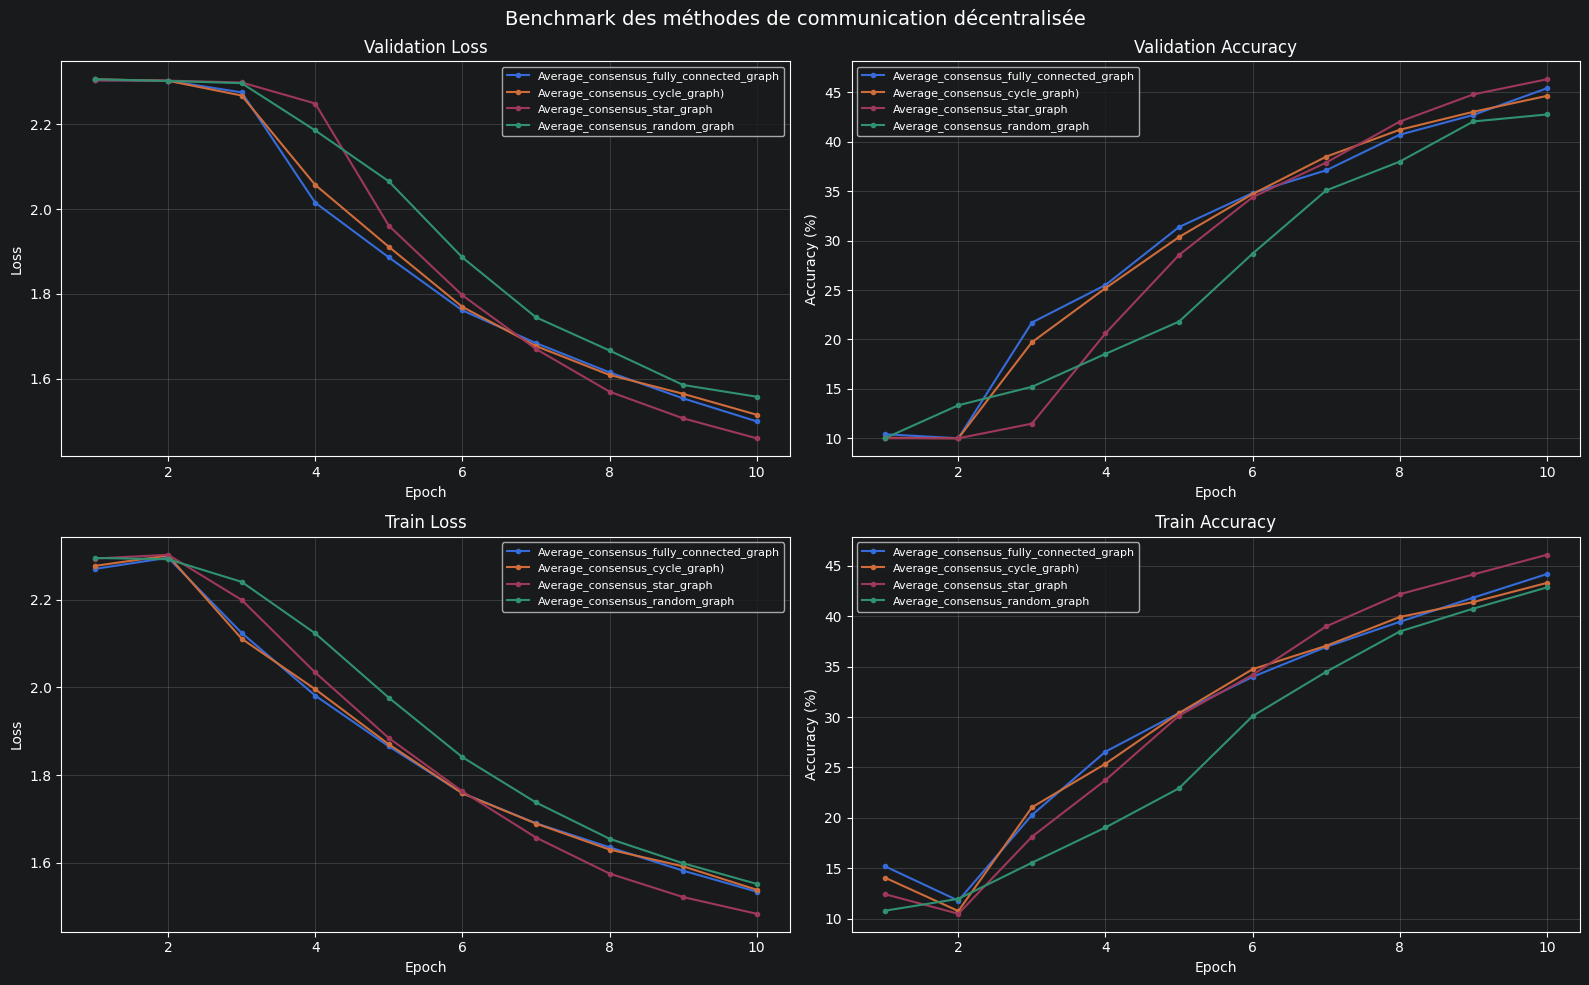

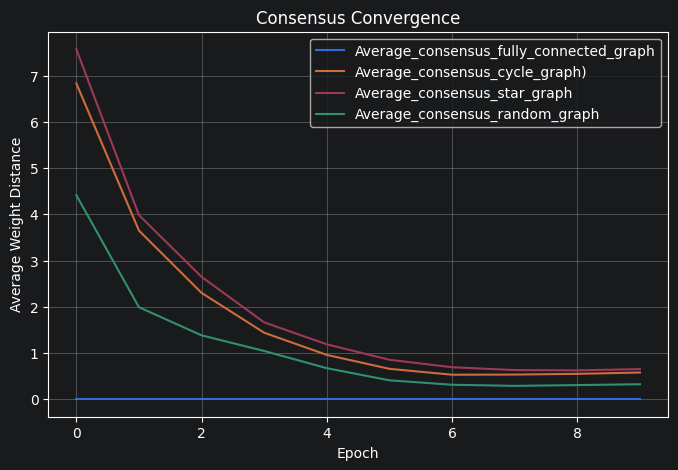

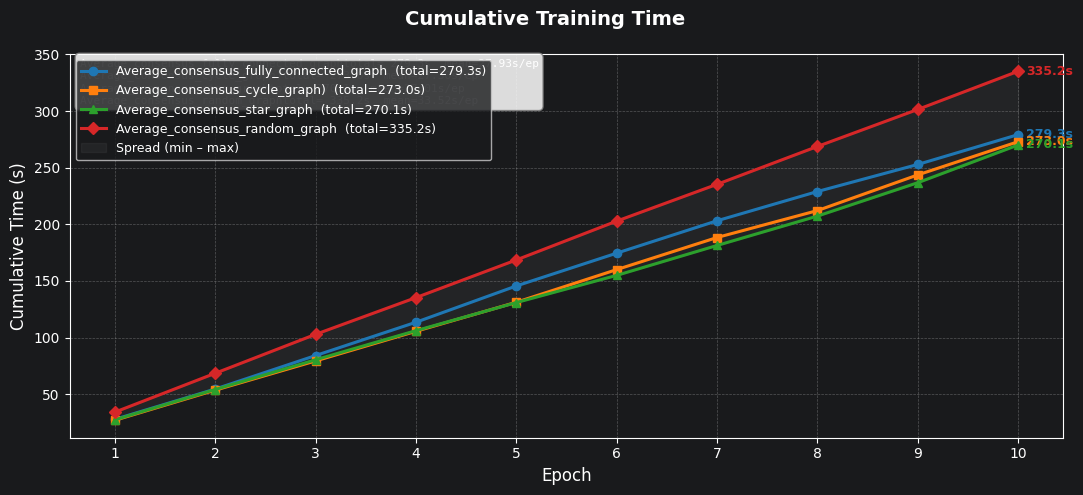

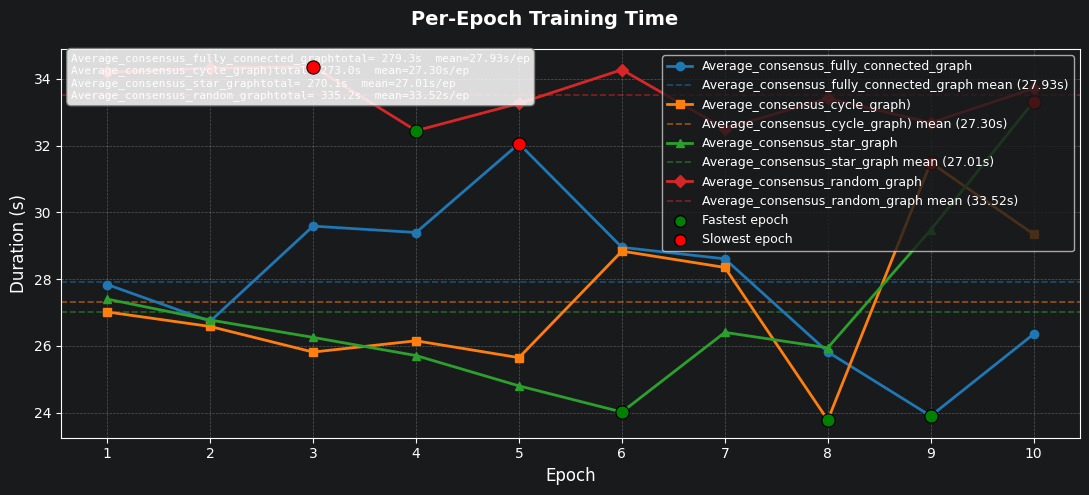


═══════════════════════════════════════════════════════
  RunResult : Average_consensus_fully_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 45.42%
  Val Loss  finale : 1.4995
  Temps total      : 279.25s
  Temps moyen/ép.  : 27.93s
  Époque la + rapide : ép.9 (23.90s)
  Époque la + lente  : ép.5 (32.06s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Average_consensus_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 47.307 MB
    Total messages    : 200
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 7.51 ms
    Synchro totale    : 75.1 ms
─────────────────────────

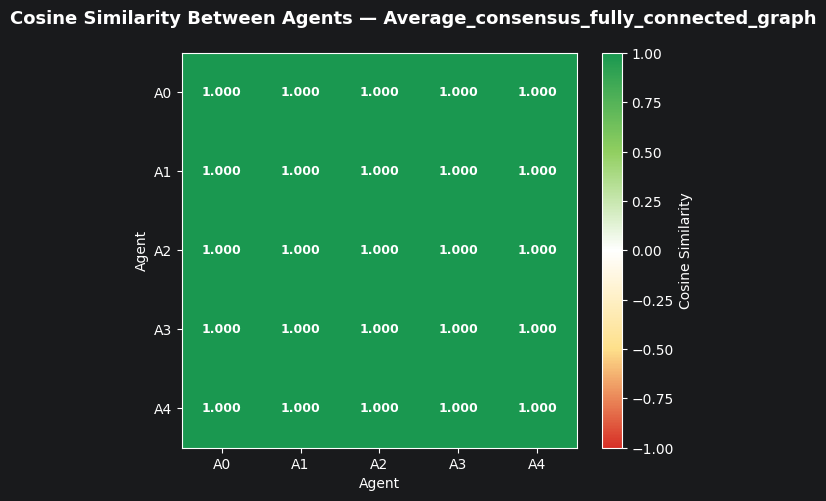

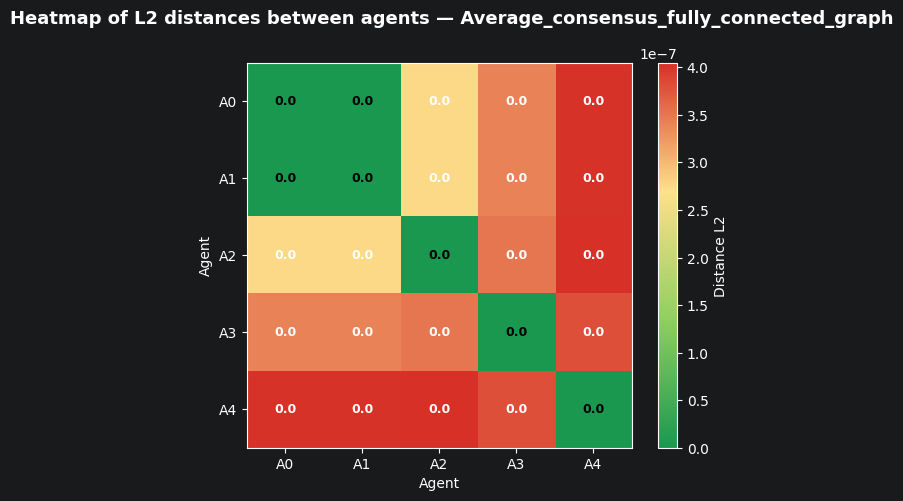

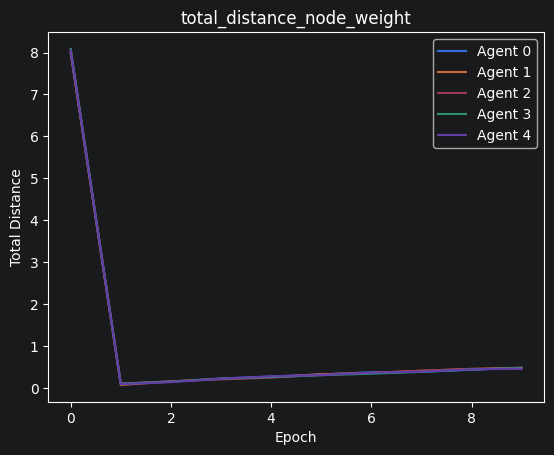

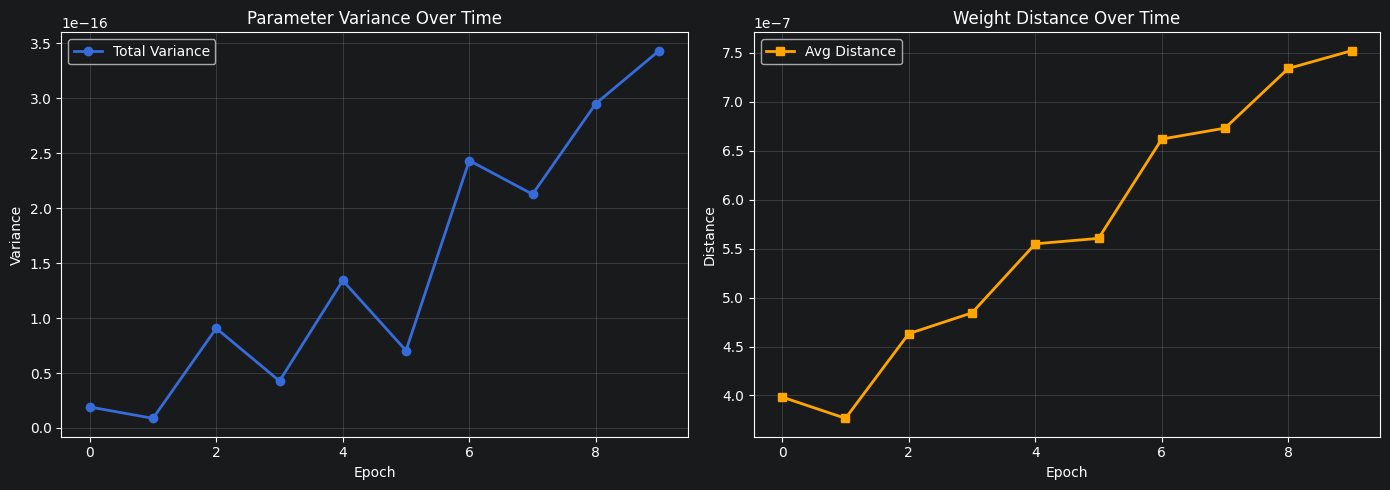


═══════════════════════════════════════════════════════
  RunResult : Average_consensus_cycle_graph)
───────────────────────────────────────────────────────
  Accuracy  finale : 44.65%
  Val Loss  finale : 1.5151
  Temps total      : 273.02s
  Temps moyen/ép.  : 27.30s
  Époque la + rapide : ép.8 (23.78s)
  Époque la + lente  : ép.9 (31.49s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Average_consensus_cycle_graph)
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 23.653 MB
    Total messages    : 100
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 6.56 ms
    Synchro totale    : 65.6 ms
───────────────────────────────────────────

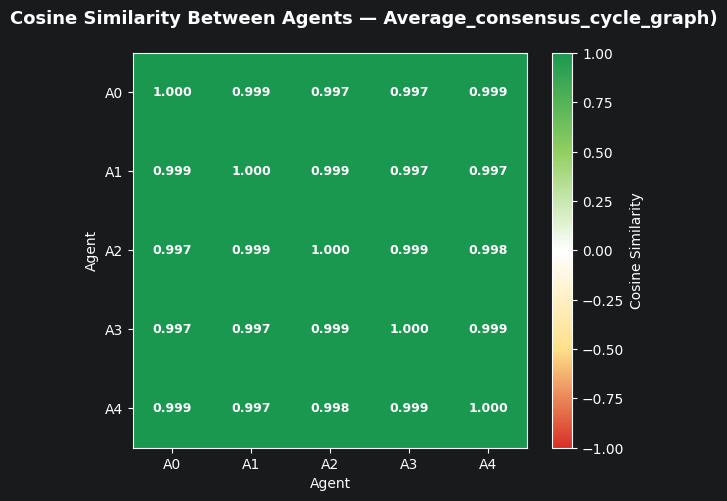

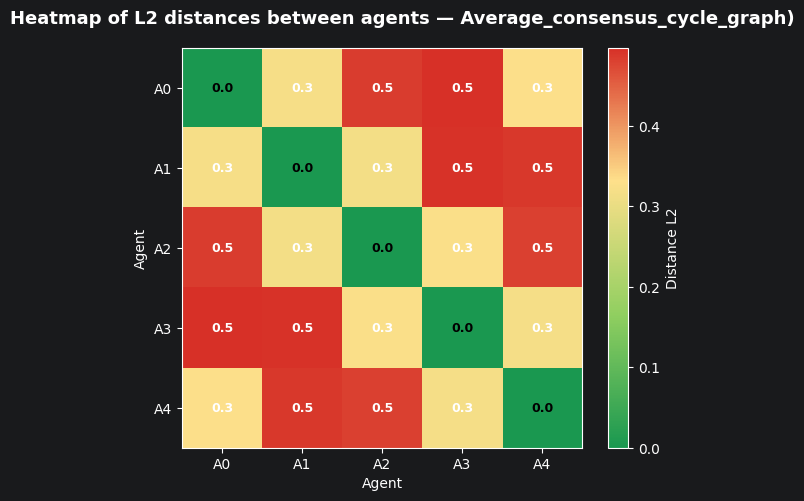

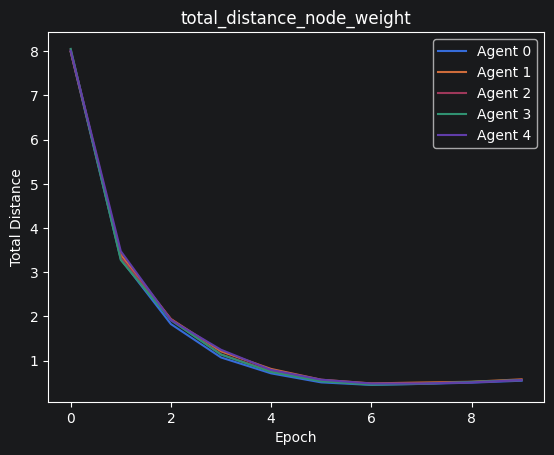

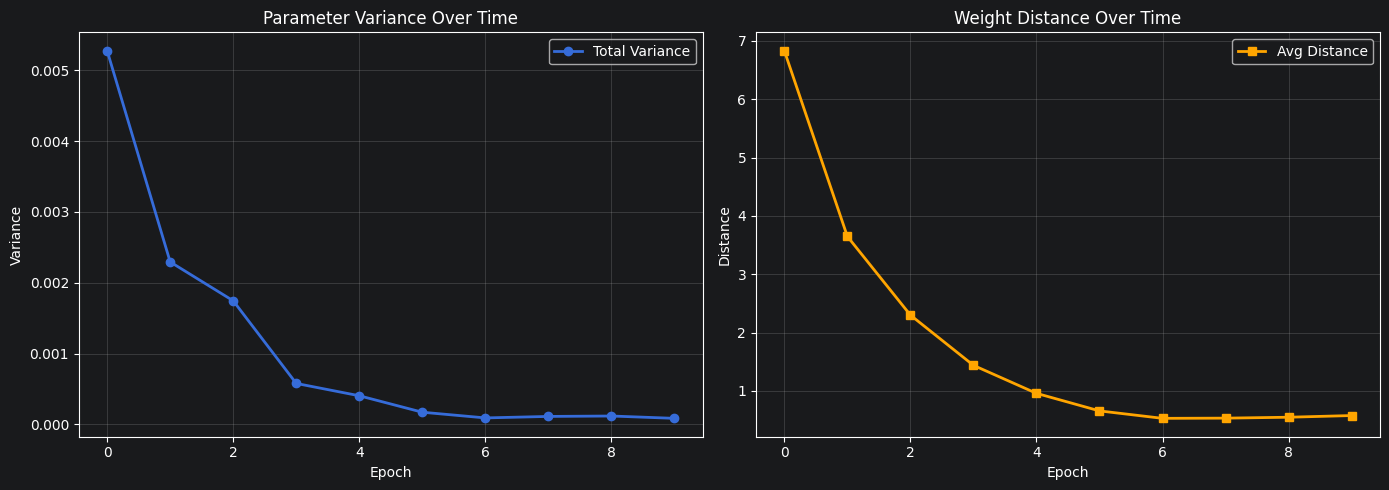


═══════════════════════════════════════════════════════
  RunResult : Average_consensus_star_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 46.33%
  Val Loss  finale : 1.4596
  Temps total      : 270.10s
  Temps moyen/ép.  : 27.01s
  Époque la + rapide : ép.6 (24.02s)
  Époque la + lente  : ép.10 (33.32s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Average_consensus_star_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 18.923 MB
    Total messages    : 80
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 5.72 ms
    Synchro totale    : 57.2 ms
───────────────────────────────────────────────

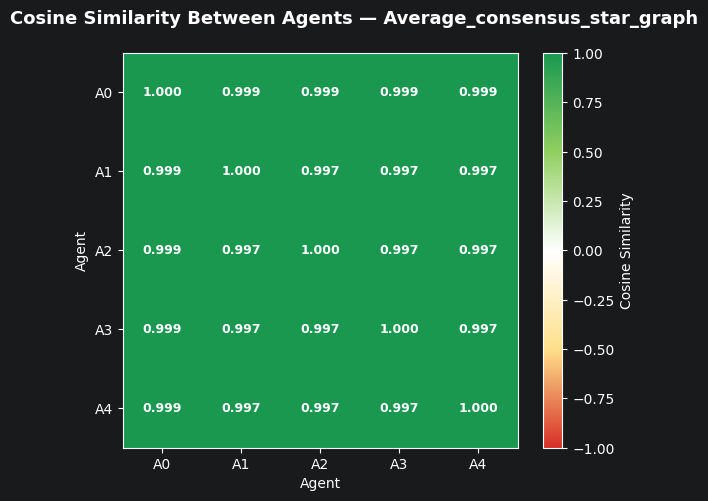

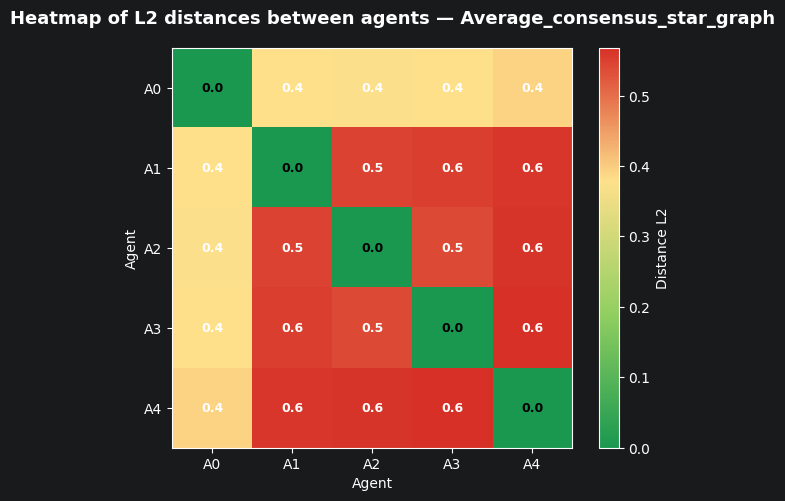

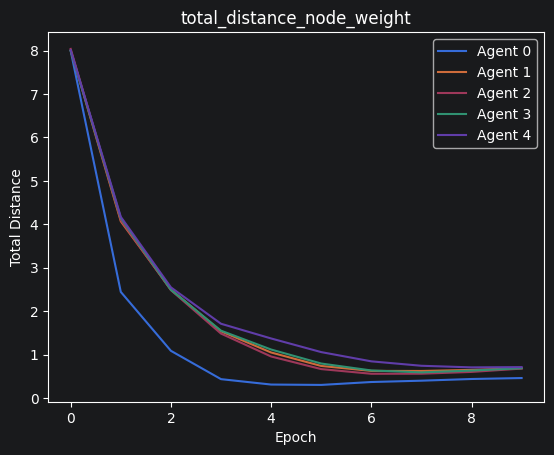

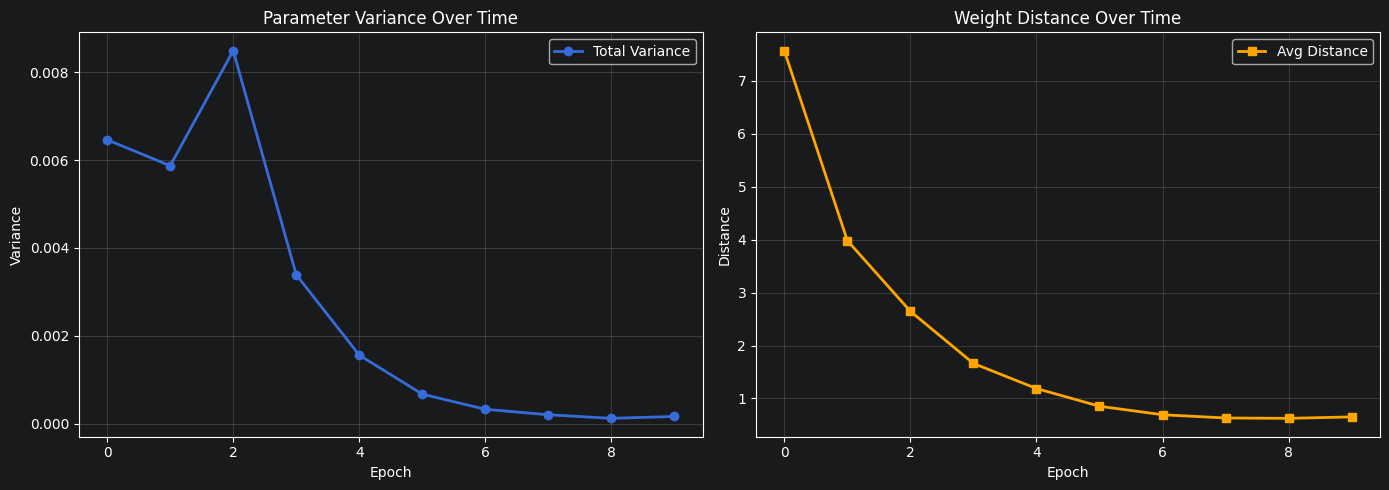


═══════════════════════════════════════════════════════
  RunResult : Average_consensus_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 42.77%
  Val Loss  finale : 1.5575
  Temps total      : 335.19s
  Temps moyen/ép.  : 33.52s
  Époque la + rapide : ép.4 (32.45s)
  Époque la + lente  : ép.3 (34.37s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Average_consensus_random_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 33.115 MB
    Total messages    : 140
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 7.24 ms
    Synchro totale    : 72.4 ms
───────────────────────────────────────────

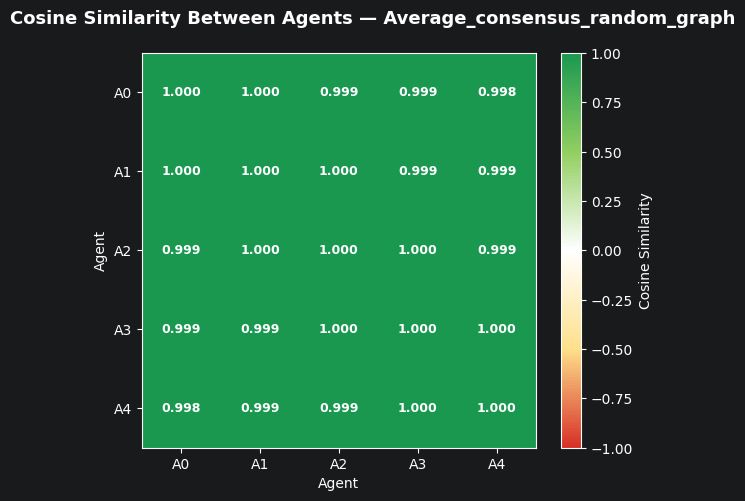

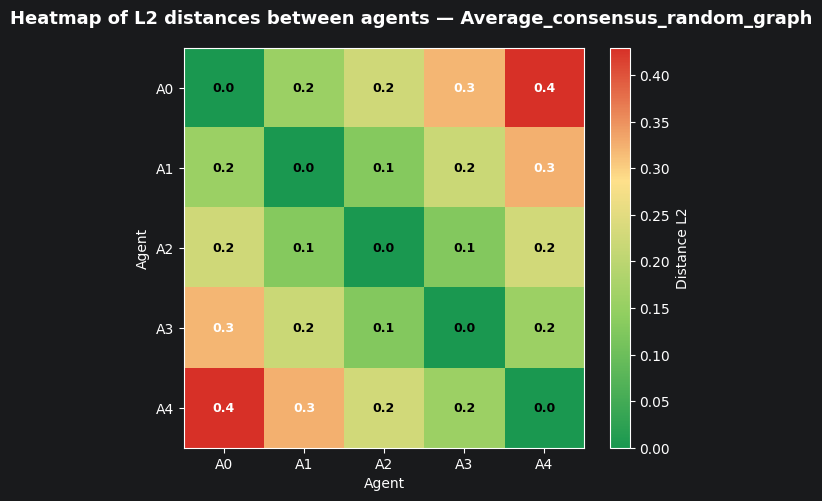

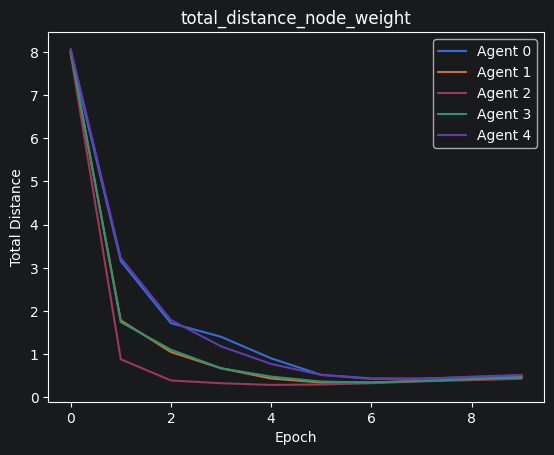

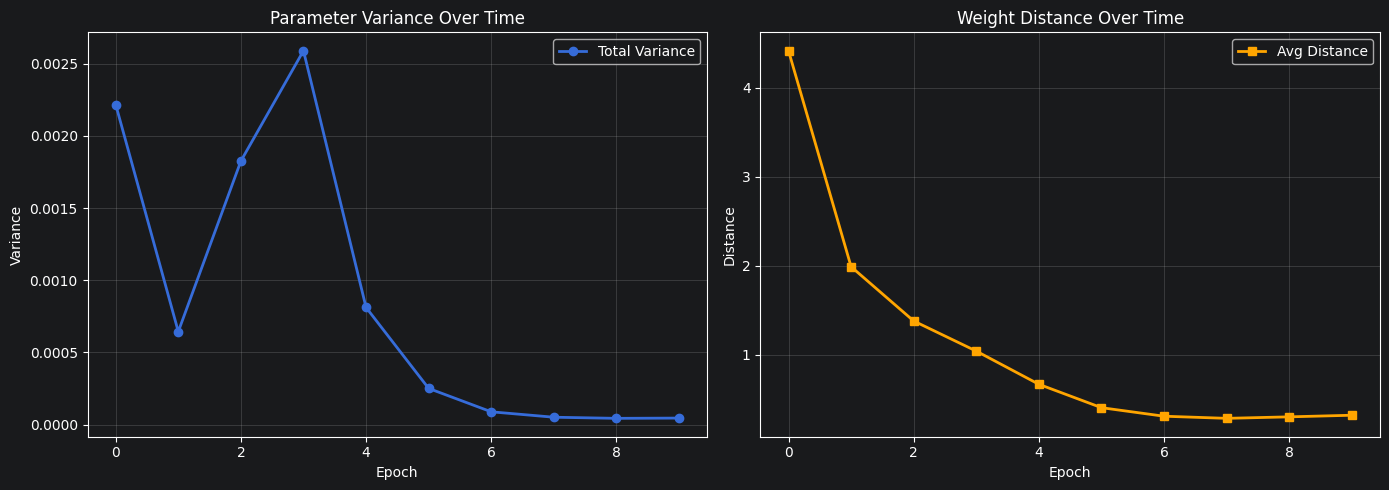

In [11]:
def Average_consensus_fully_connected_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Average_consensus_cycle_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Average_consensus_star_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Average_consensus_random_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"Average_consensus_fully_connected_graph" : Average_consensus_fully_connected_graph,
    f"Average_consensus_cycle_graph)"          : Average_consensus_cycle_graph,
    f"Average_consensus_star_graph"            : Average_consensus_star_graph,
    f"Average_consensus_random_graph"          : Average_consensus_random_graph
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    result.comm_cost.summary()
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()


C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775

  RUN — méthode : AC_K_fully_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 4 start
Agent 3 start
Agent 0 start
Agent 1 start
Agent 2 start
Model4 - Acc:13.06 % - Loss:2.286180598974228 %
Model3 - Acc:12.68 % - Loss:2.294935063123703 %
Model0 - Acc:11.87 % - Loss:2.295817204236984 %
Model1 - Acc:13.84 % - Loss:2.2741774400472643 %
Model2 - Acc:12.26 % - Loss:2.2981824893951415 %
[DEBUG] set_epoch_messages called → 100 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 100
[DEBUG] _record epoch=0 → n_messages=100
  [Epoch 1/10] ✓  time=34.17s  cumulative=34.17s
  [Epoch 2/10] threads started …

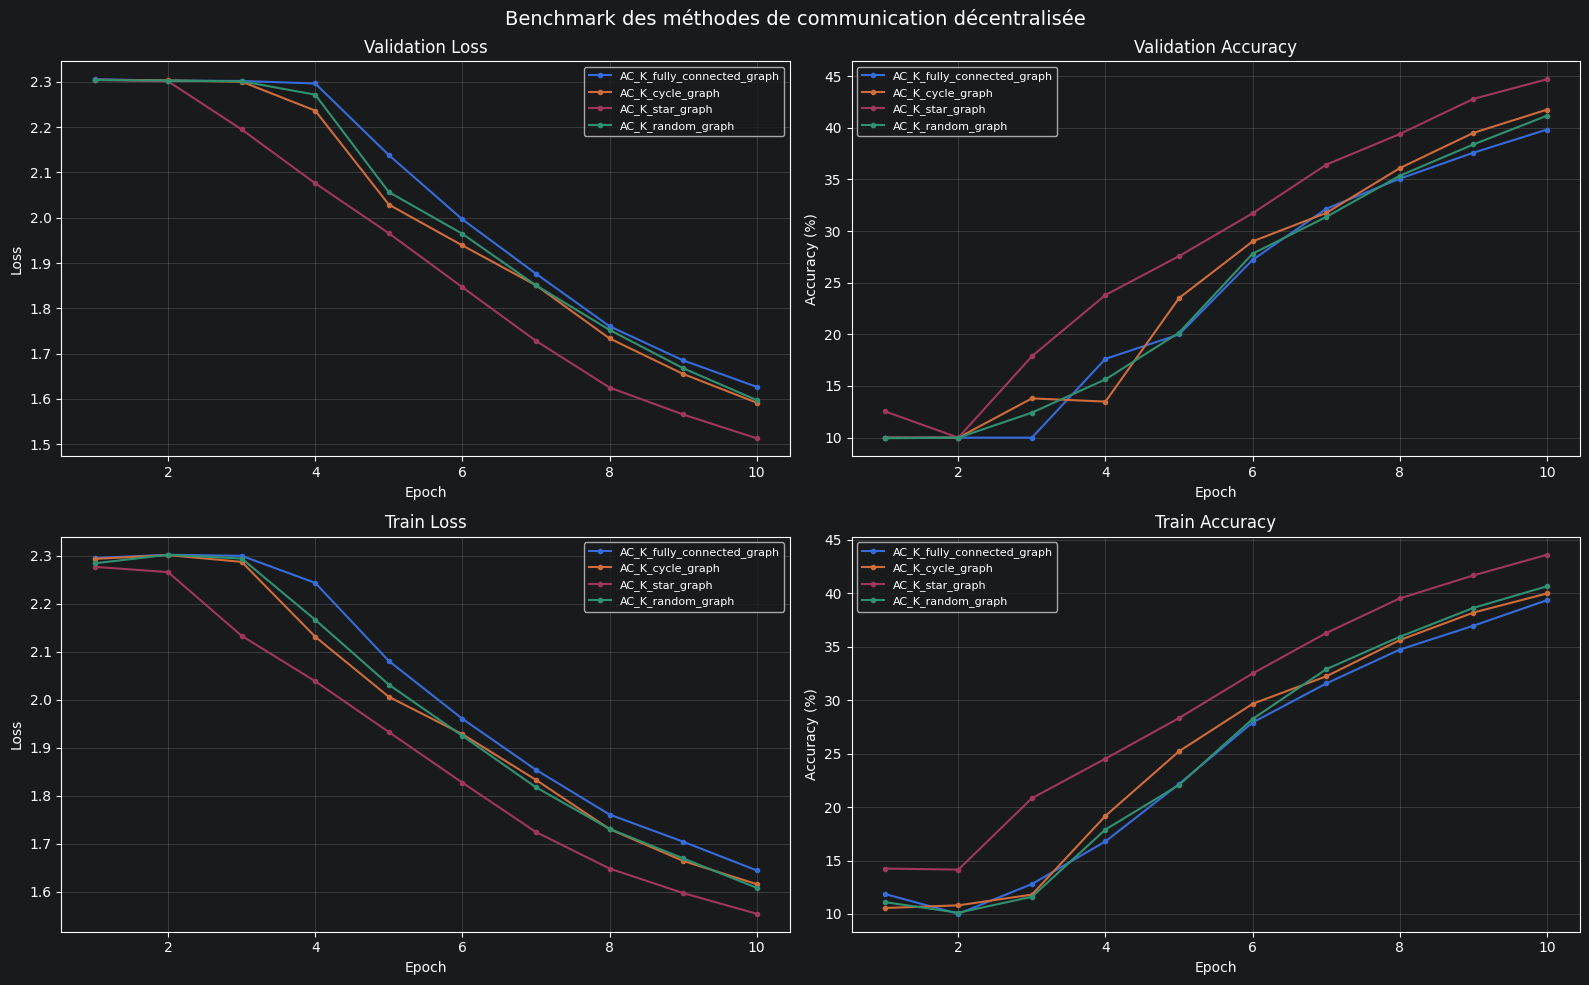

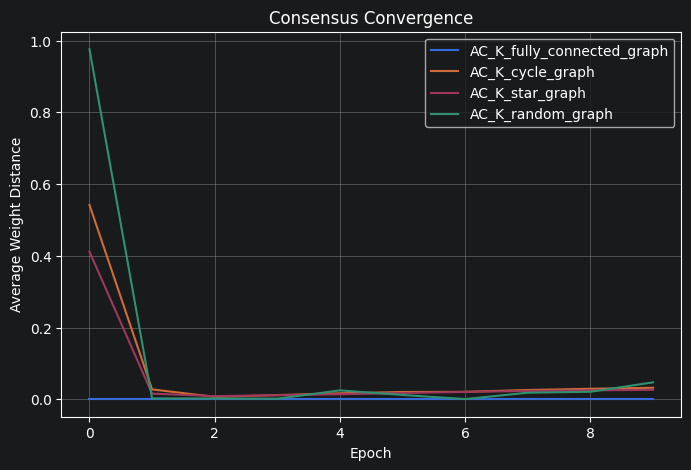

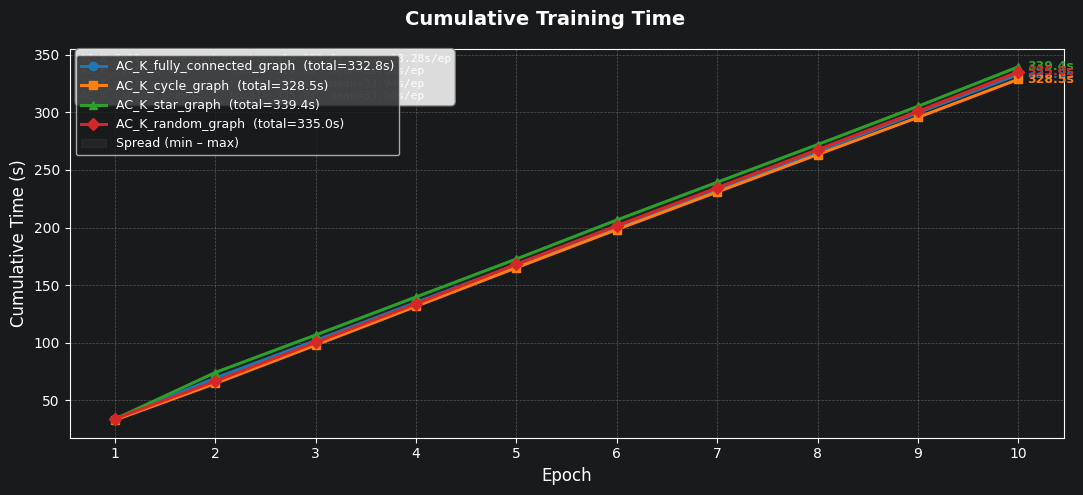

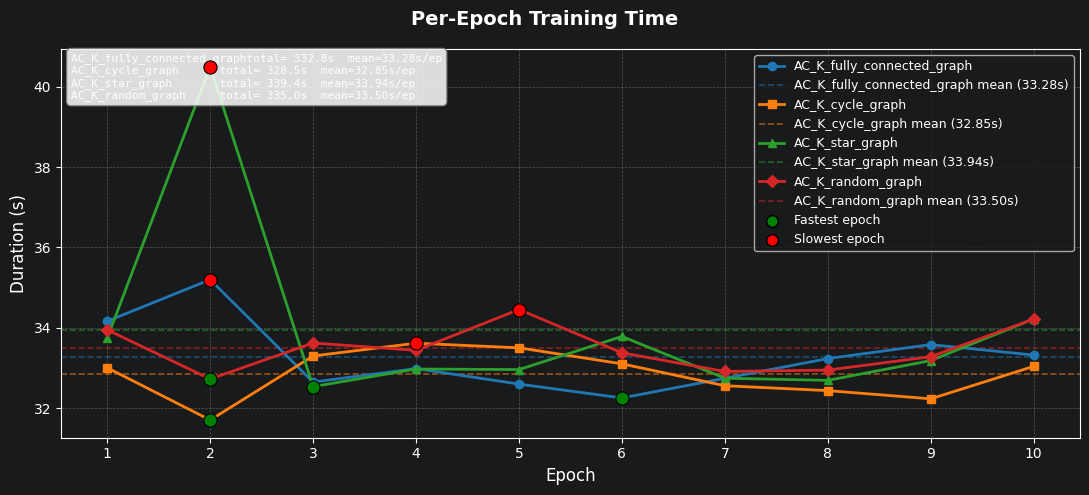


═══════════════════════════════════════════════════════
  RunResult : AC_K_fully_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 39.82%
  Val Loss  finale : 1.6268
  Temps total      : 332.77s
  Temps moyen/ép.  : 33.28s
  Époque la + rapide : ép.6 (32.26s)
  Époque la + lente  : ép.2 (35.20s)
═══════════════════════════════════════════════════════


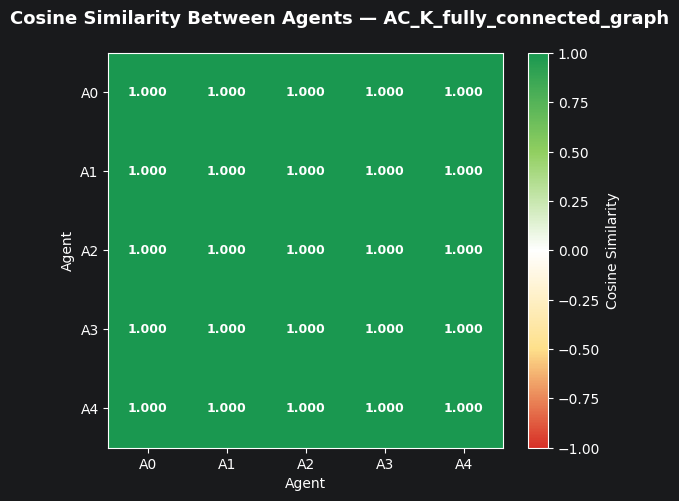

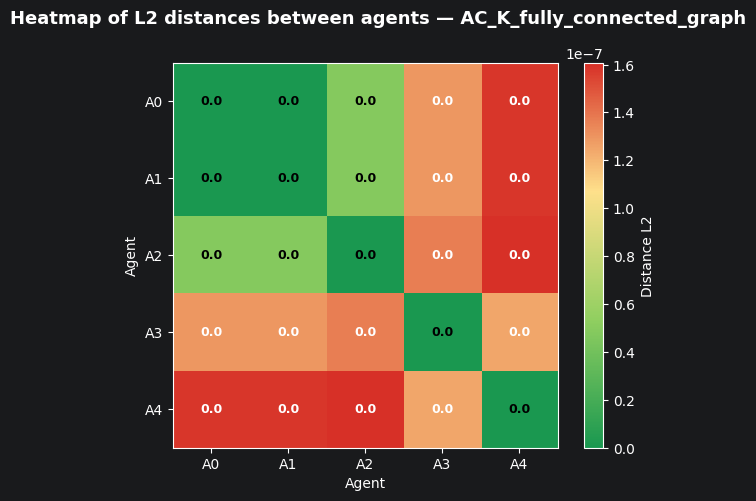

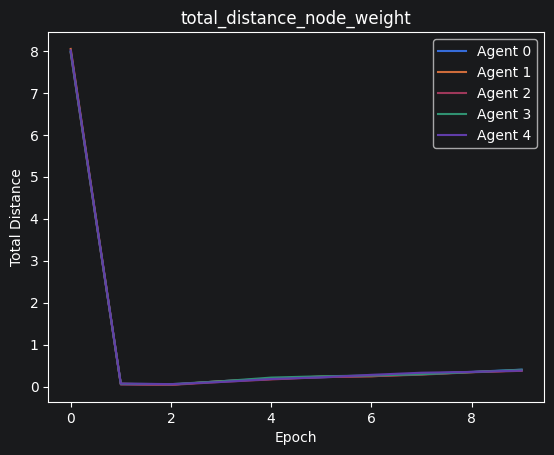

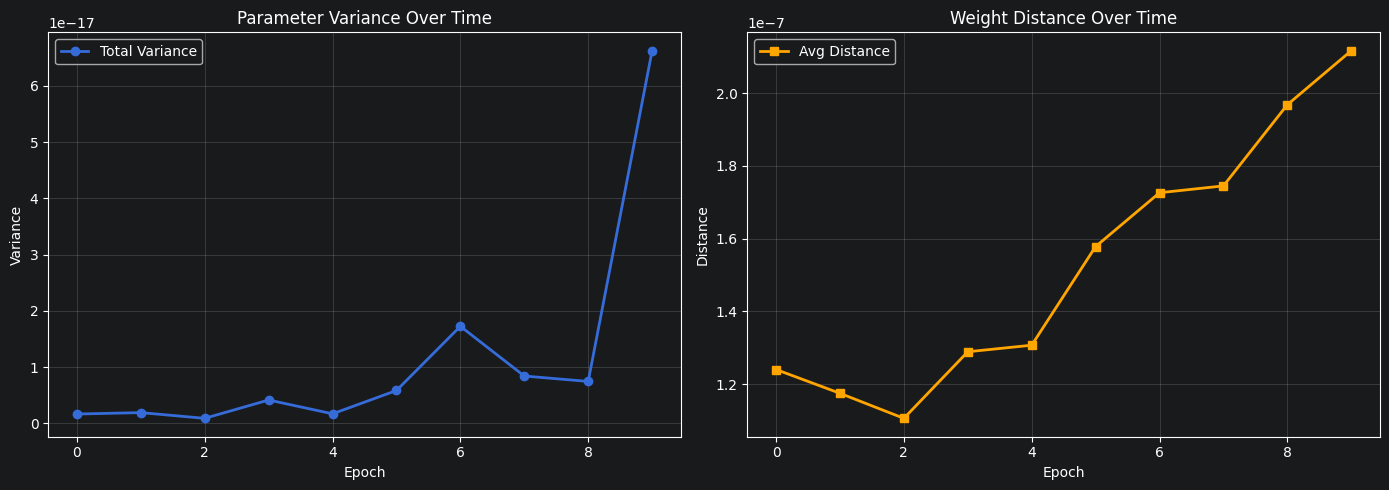


══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_K_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 236.534 MB
    Total messages    : 1,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 119.54 ms
    Synchro totale    : 1195.4 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  RunResult : AC_K_cycle_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 41.75%
  Val Loss  finale : 1.5919
  Temps total      : 328.

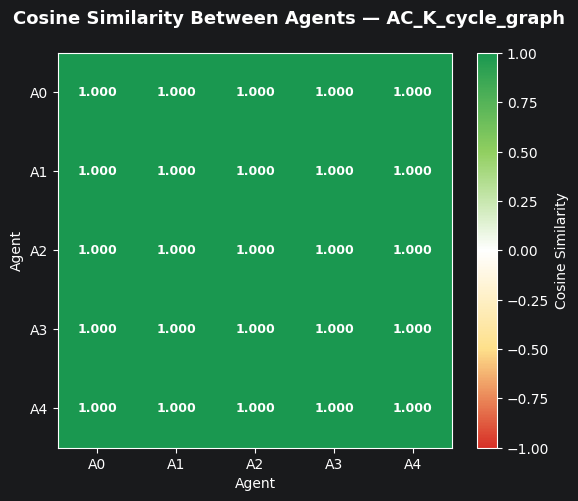

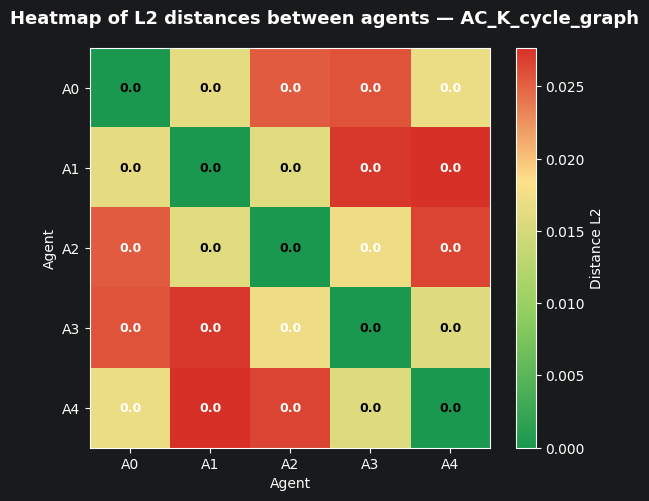

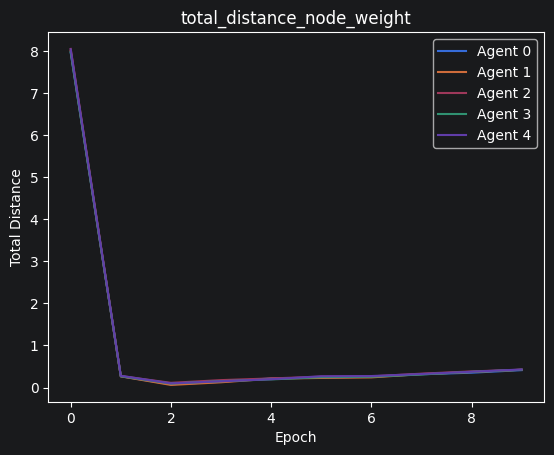

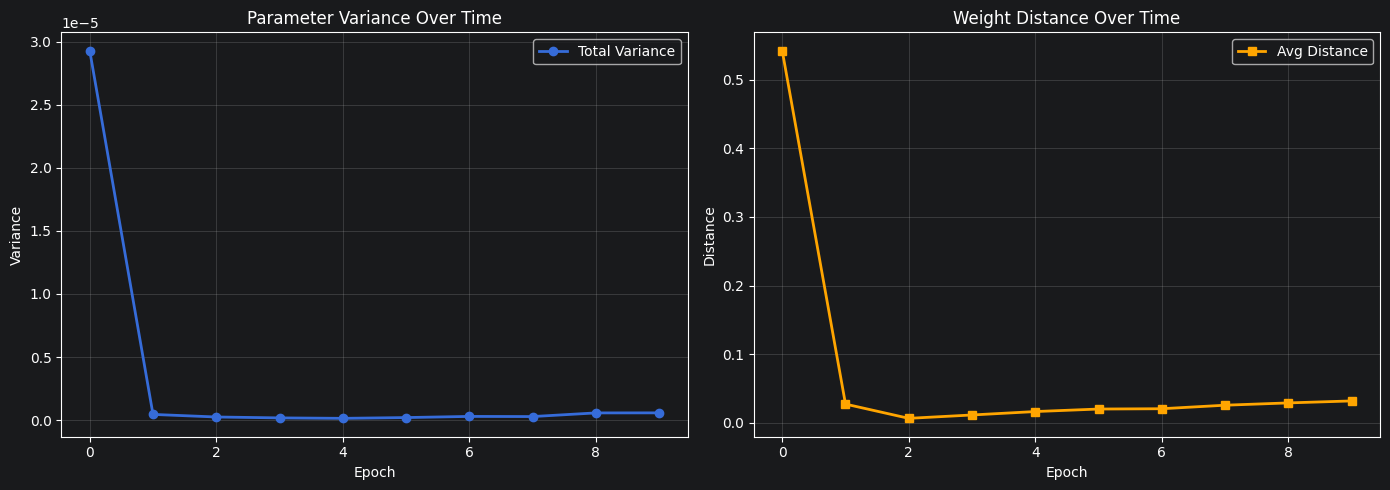


══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_K_cycle_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 118.267 MB
    Total messages    : 500
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 113.57 ms
    Synchro totale    : 1135.7 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  RunResult : AC_K_star_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 44.69%
  Val Loss  finale : 1.5133
  Temps total      : 339.37s
  Temps m

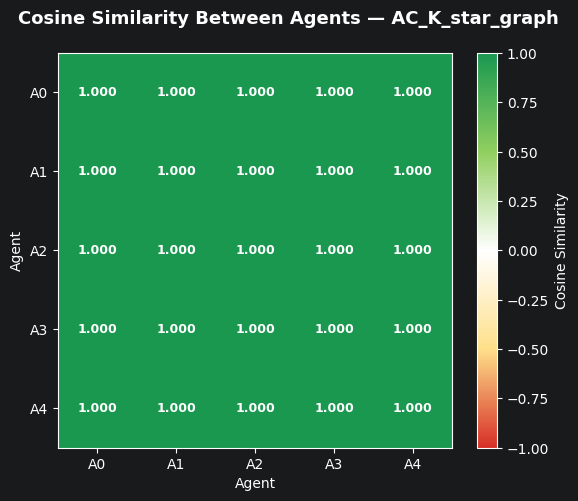

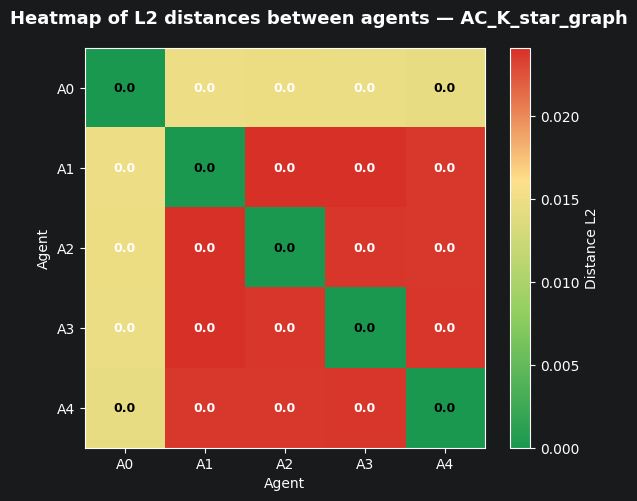

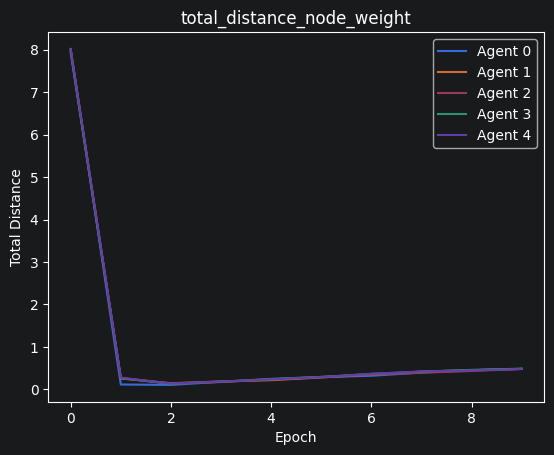

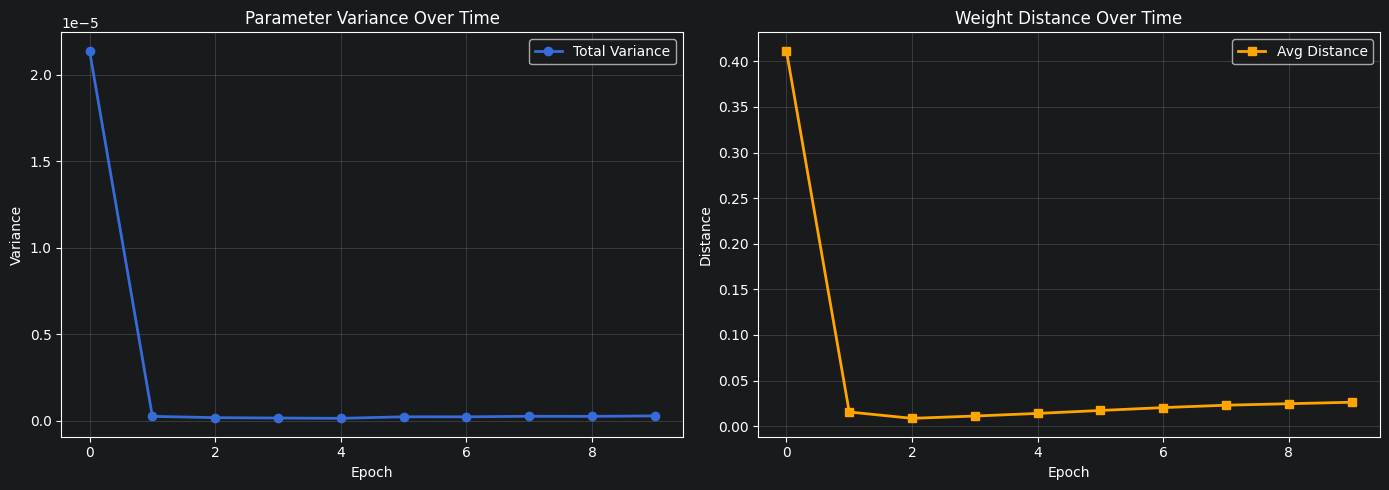


══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_K_star_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 94.614 MB
    Total messages    : 400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 110.99 ms
    Synchro totale    : 1109.9 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  RunResult : AC_K_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 41.16%
  Val Loss  finale : 1.5975
  Temps total      : 334.96s
  Temps m

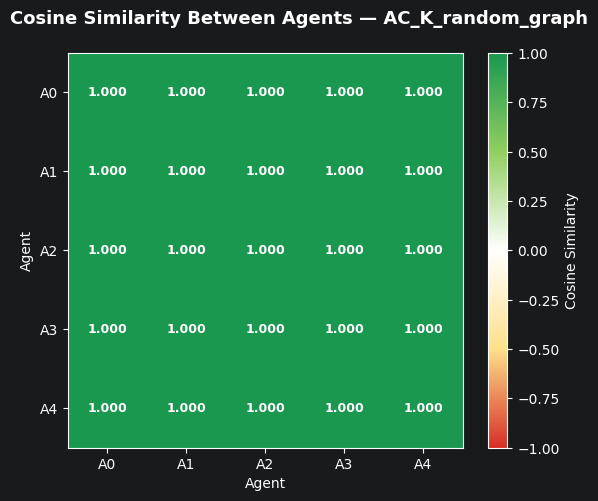

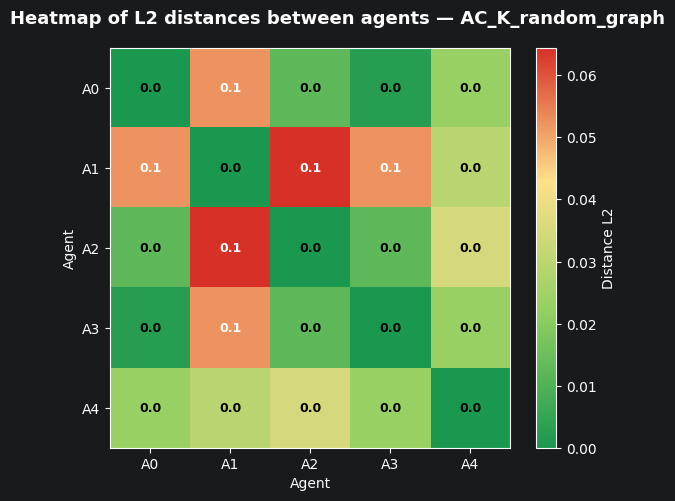

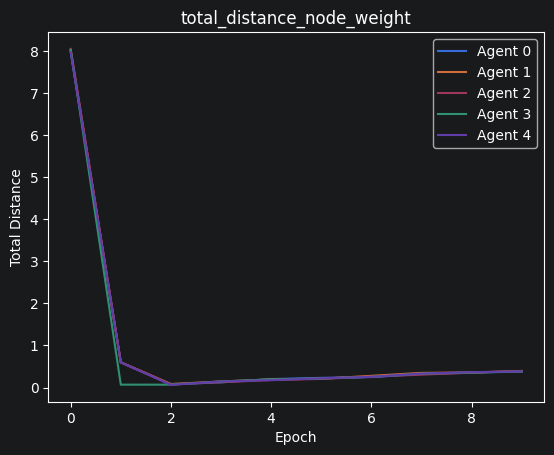

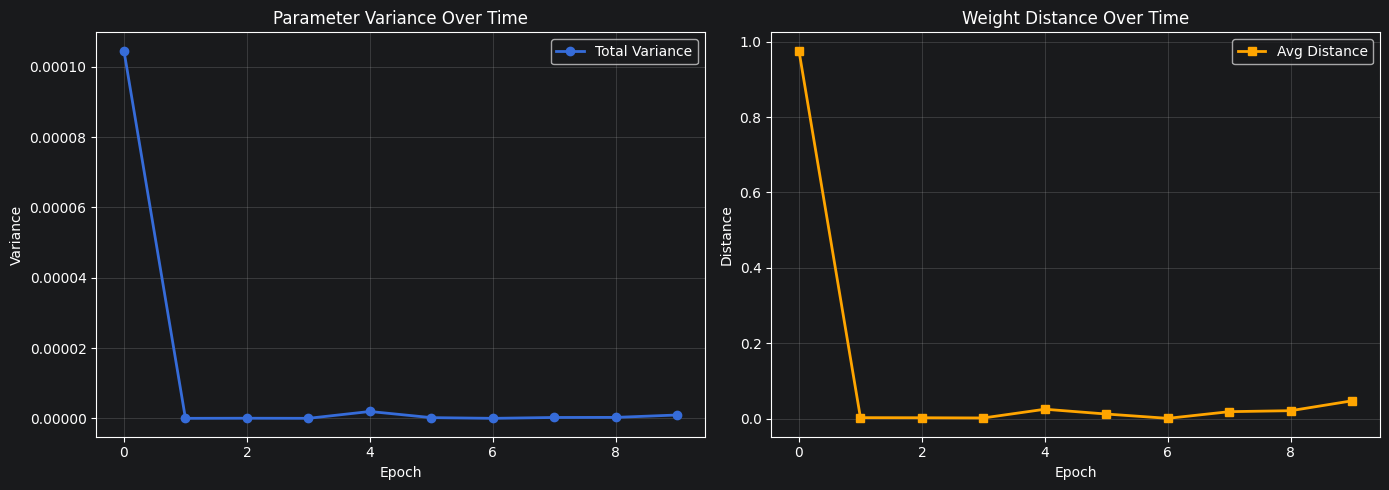


══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_K_random_graph
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 146.651 MB
    Total messages    : 620
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 118.97 ms
    Synchro totale    : 1189.7 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════



In [12]:
def Average_consensus_K_fully_connected_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_K_cycle_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_K_star_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_K_random_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.random_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_K_fully_connected_graph":   Average_consensus_K_fully_connected_graph,
    "AC_K_cycle_graph":             Average_consensus_K_cycle_graph,
    "AC_K_star_graph":              Average_consensus_K_star_graph,
    "AC_K_random_graph":            Average_consensus_K_random_graph,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()
    result.comm_cost.summary()

C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550

  RUN — méthode : Sequential_AC_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550
  [Epoch 1/20] threads started …
Agent 9 start
Agent 0 start
Agent 8 start
Agent 2 start
Agent 1 start
Agent 3 start
Agent 4 start
Agent 6 start
Agent 5 start
Agent 7 start
Model9 - Acc:9.92 % - Loss:2.302785533905029 %
Model0 - Acc:13.22 % - Loss:2.2932196826934814 %
Model8 - Acc:10.74 % - Loss:2.3015179681777953 %
Model2 - Acc:10.96 % - Loss:2.293842730998993 %
Model1 - Acc:11.0 % - Loss:2.3005014724731447 %
Model3 - Acc:10.14 % - Loss:2.302949429512024 %
Model4 - Acc:11.58 % - Loss:2.3004739899635314 %
Model6 - Acc:10.78 % - Loss:2.3003982377052306 %
Model5 - Acc:11.28 % - Loss:2.29981516122818 %
Model7 - Acc:12.9 % - Loss:2.3005762968063355 %
[DEBUG] set_epoch_messages called → 90 messages
[DEBUG] _resolve_n_messages → _epoch_n_messa

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000017C09D626C0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 7 : [Errno 22] Invalid argument
Agent 1 start
Agent 8 start
Agent 6 start
Agent 0 start
Agent 9 start
Agent 2 start
Agent 3 start
Agent 5 start
Agent 4 start
Model1 - Acc:41.92 % - Loss:1.603234782099724 %
Model8 - Acc:41.64 % - Loss:1.6092346429824829 %
Model6 - Acc:41.04 % - Loss:1.6151453107595444 %
Model0 - Acc:40.78 % - Loss:1.6131449731588363 %
Model9 - Acc:41.84 % - Loss:1.5930559573173524 %
Model2 - Acc:41.04 % - Loss:1.6140001922845841 %
Model3 - Acc:43.0 % - Loss:1.6113731169700622 %
Model5 - Acc:41.26 % - Loss:1.612996089220047 %
Model4 - Acc:38.94 % - Loss:1.6337809228897096 %
[DEBUG] set_epoch_messages called → 90 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 90
[DEBUG] _record epoch=12 → n_messages=90
  [Epoch 13/20] ✓  time=41.25s  cumulative=576.02s
  [Epoch 14/20] threads started …
Agent 5 start
Agent 3 start
Agent 4 start
Agent 2 start
Agent 8 start
Agent 7 start
Agent 9 start
Agent 1 start
Agent 0 start
Agent 6 start
Model5 - Acc:42.14 % - L

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000017C09D626C0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


...

Erreur agent 4 : [Errno 22] Invalid argument
Agent 2 start
Agent 5 start
Agent 3 start
Agent 6 start
Agent 8 start
Agent 1 start
Agent 9 start
Agent 7 start
Agent 0 start
Model2 - Acc:10.22 % - Loss:2.3027662701606753 %
Model5 - Acc:10.38 % - Loss:2.302648817539215 %
Model3 - Acc:9.58 % - Loss:2.302841142654419 %
Model6 - Acc:9.74 % - Loss:2.302671203613281 %
Model8 - Acc:10.7 % - Loss:2.302212749481201 %
Model1 - Acc:9.94 % - Loss:2.3029440393447875 %
Model9 - Acc:10.32 % - Loss:2.302584023952484 %
Model7 - Acc:9.68 % - Loss:2.3026152663230897 %
Model0 - Acc:10.08 % - Loss:2.302812170982361 %
[DEBUG] set_epoch_messages called → 38 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 38
[DEBUG] _record epoch=2 → n_messages=38
  [Epoch 3/20] ✓  time=40.81s  cumulative=128.13s
  [Epoch 4/20] threads started …
Agent 1 start
Agent 9 start
Agent 8 start
Agent 0 start
Agent 7 start
Agent 6 start
Agent 5 start
Agent 2 start
Agent 4 start
Agent 3 start
Model1 - Acc:9.88 % - Loss:2.302754

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000017C09D626C0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 7 : [Errno 22] Invalid argument
Agent 3 start
Agent 4 start
Agent 5 start
Agent 2 start
Agent 9 start
Agent 8 start
Agent 1 start
Agent 6 start
Agent 0 start
Model3 - Acc:28.44 % - Loss:1.924066234588623 %
Model5 - Acc:27.12 % - Loss:1.9482413721084595 %
Model4 - Acc:27.72 % - Loss:1.9356731514930725 %
Model2 - Acc:27.92 % - Loss:1.9475733115673066 %
Model8 - Acc:27.44 % - Loss:1.9553149280548097 %
Model9 - Acc:26.88 % - Loss:1.9532923381328582 %
Model6 - Acc:28.1 % - Loss:1.941630345582962 %
Model1 - Acc:28.0 % - Loss:1.9460316841602325 %
Model0 - Acc:27.82 % - Loss:1.9435916941165925 %
[DEBUG] set_epoch_messages called → 44 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 44
[DEBUG] _record epoch=17 → n_messages=44
  [Epoch 18/20] ✓  time=39.65s  cumulative=767.44s
  [Epoch 19/20] threads started …
Agent 6 start
Agent 1 start
Agent 7 start
Agent 0 start
Agent 8 start
Agent 9 start
Agent 5 start
Agent 3 start
Agent 4 start
Agent 2 start
Model6 - Acc:30.1 % - Los

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000017C09D626C0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 3 : [Errno 22] Invalid argument
Agent 8 start
Agent 0 start
Agent 9 start
Agent 2 start
Agent 1 start
Agent 4 start
Agent 7 start
Agent 6 start
Agent 5 start
Model8 - Acc:30.54 % - Loss:1.8424920408725738 %
Model0 - Acc:31.36 % - Loss:1.8224974732398986 %
Model9 - Acc:30.84 % - Loss:1.8333648736476897 %
Model2 - Acc:31.66 % - Loss:1.832855348587036 %
Model1 - Acc:31.56 % - Loss:1.8377049303054809 %
Model4 - Acc:30.96 % - Loss:1.8302587325572968 %
Model7 - Acc:31.72 % - Loss:1.8327327032089233 %
Model6 - Acc:31.08 % - Loss:1.8354092261791228 %
Model5 - Acc:30.02 % - Loss:1.840066445827484 %
[DEBUG] set_epoch_messages called → 44 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 44
[DEBUG] _record epoch=19 → n_messages=44
  [Epoch 20/20] ✓  time=38.95s  cumulative=848.86s

──────────────────────────────────────────────────
  Training complete — <EpochTimer epochs=20 | total=848.86s | mean=42.44s/ep | fastest=ep20(38.95s) | slowest=ep2(45.70s)>
──────────────────────

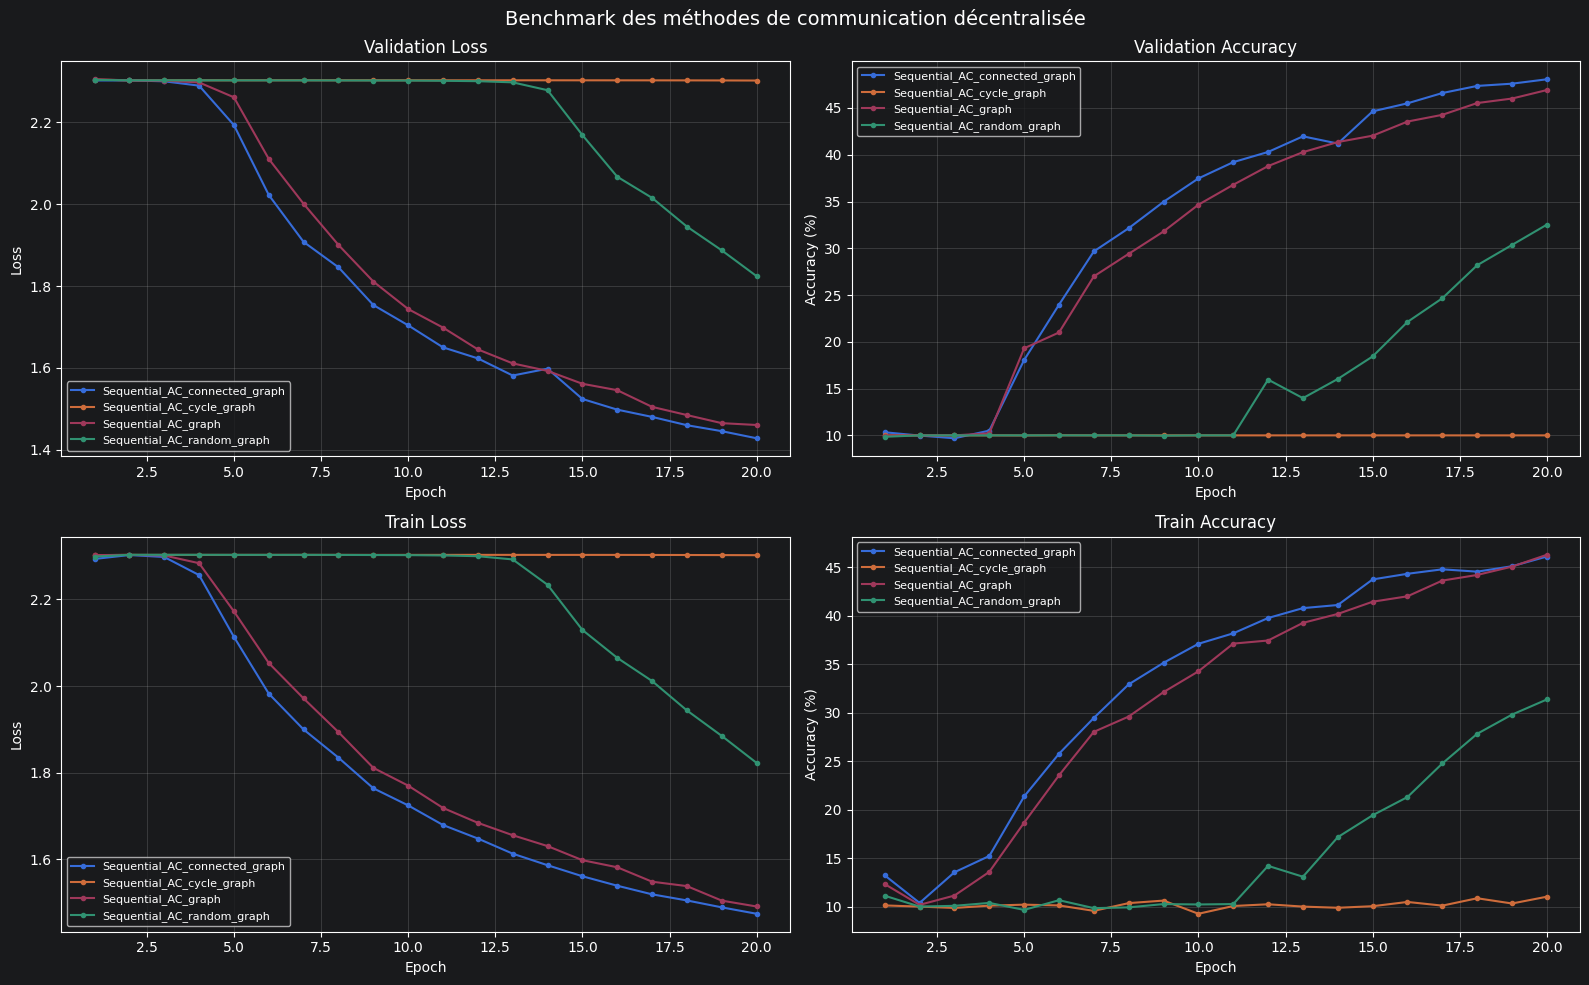

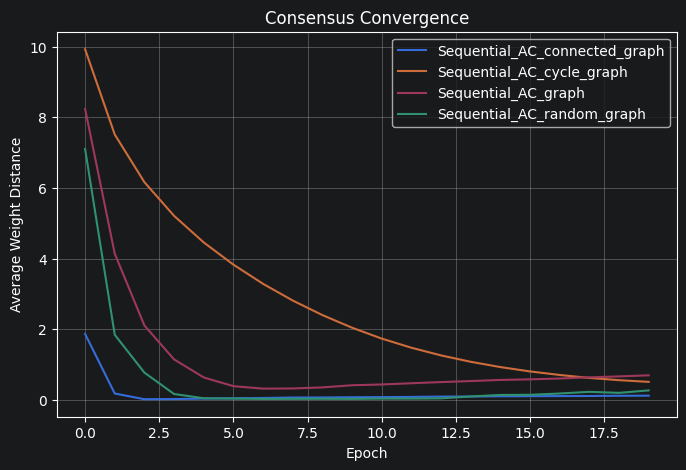

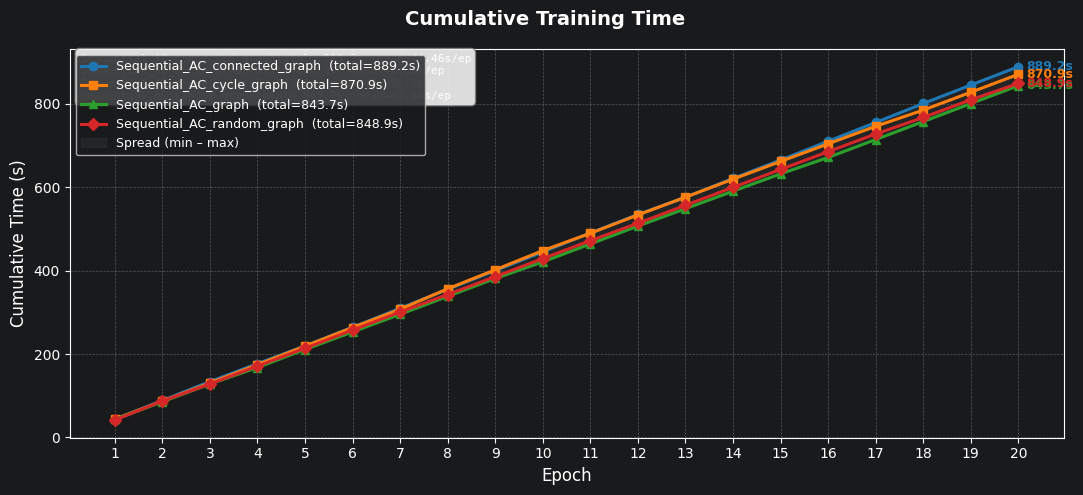

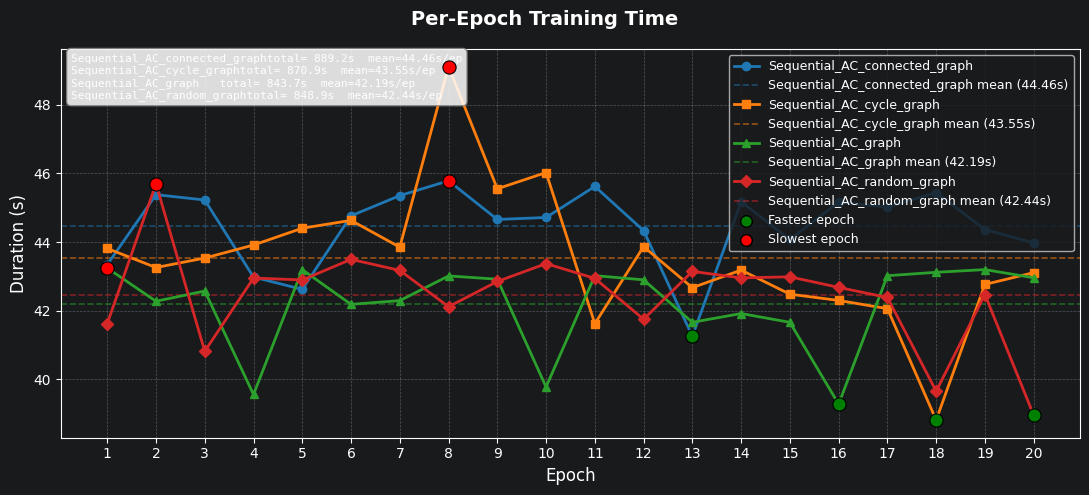


═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 48.07%
  Val Loss  finale : 1.4282
  Temps total      : 889.23s
  Temps moyen/ép.  : 44.46s
  Époque la + rapide : ép.13 (41.25s)
  Époque la + lente  : ép.8 (45.79s)
═══════════════════════════════════════════════════════


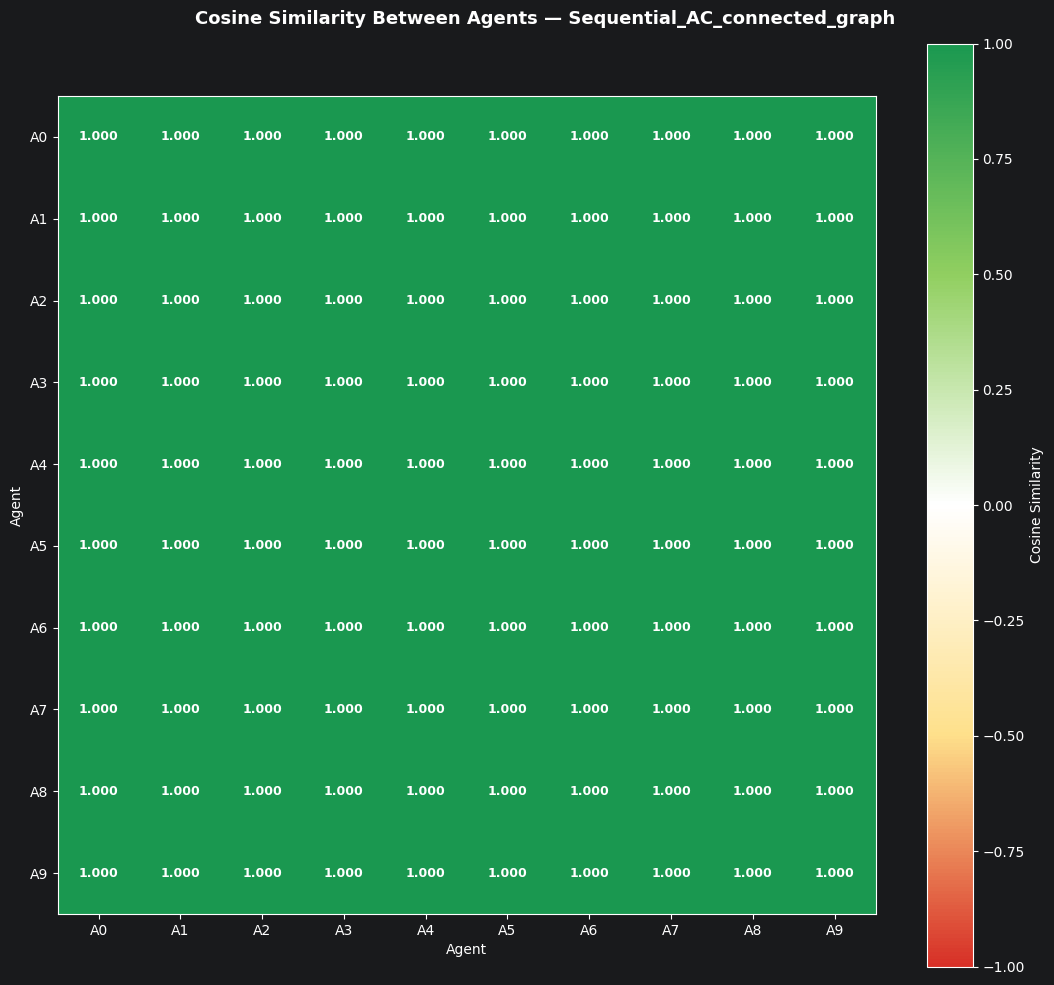

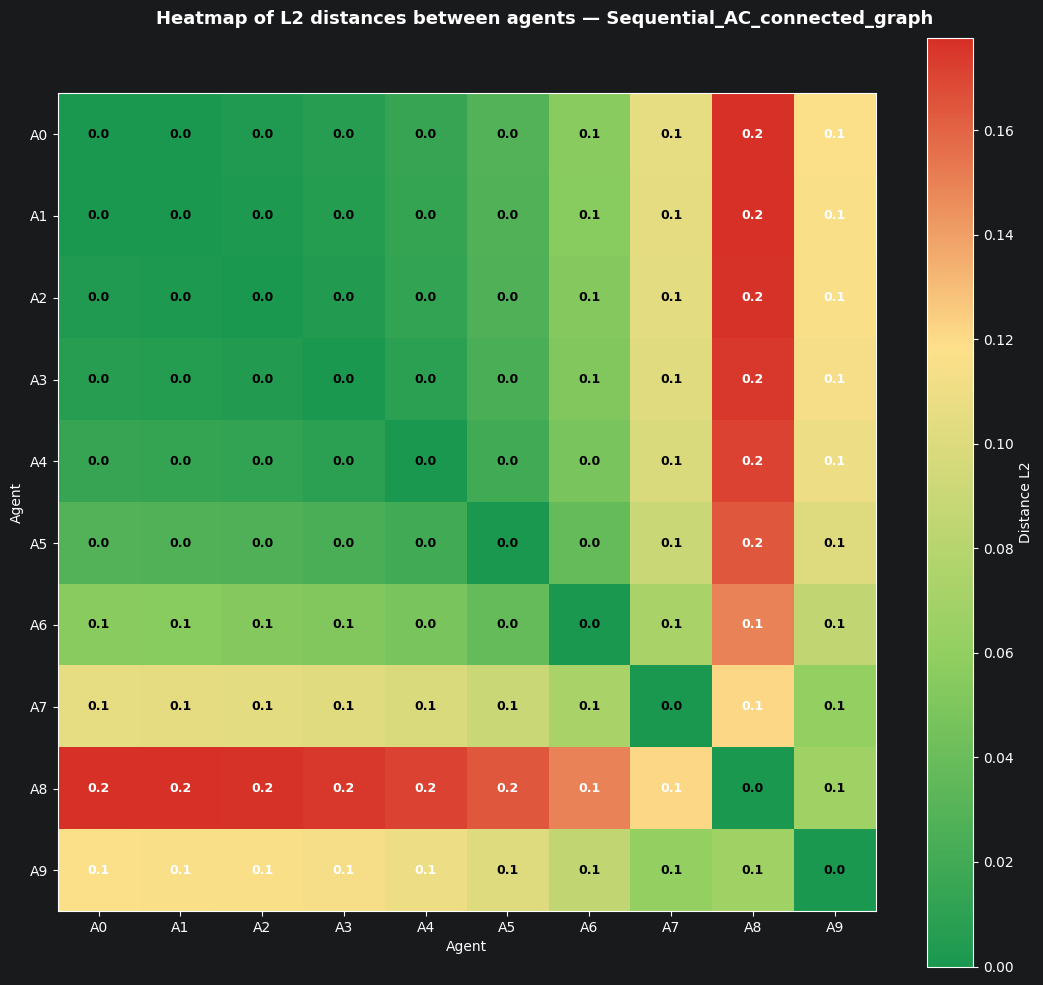

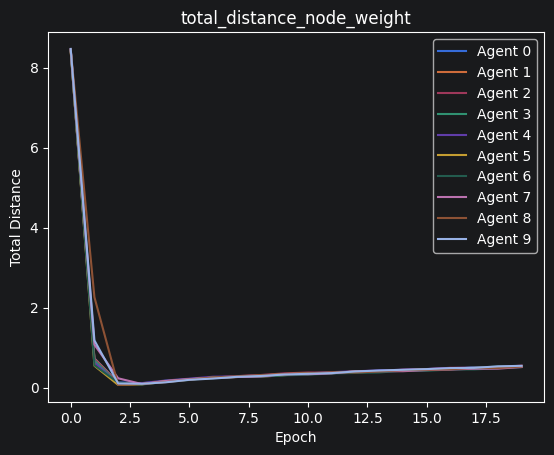

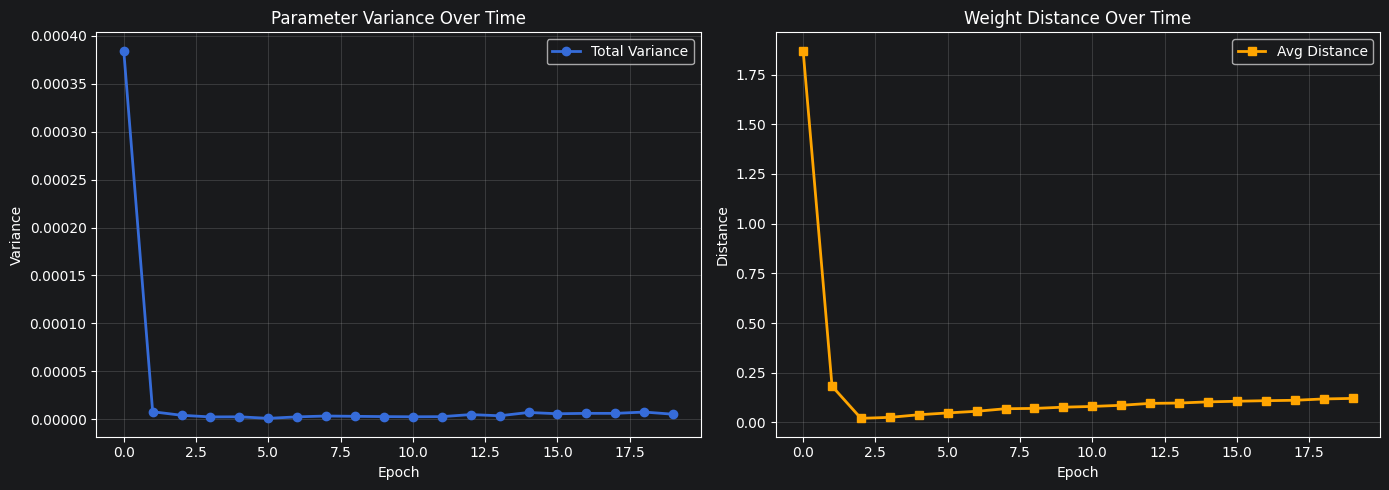


══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 20
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 425.761 MB
    Total messages    : 1,800
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 79.20 ms
    Synchro totale    : 1584.0 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_cycle_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 10.00%
  Val Loss  finale : 2.3021
  Temps total

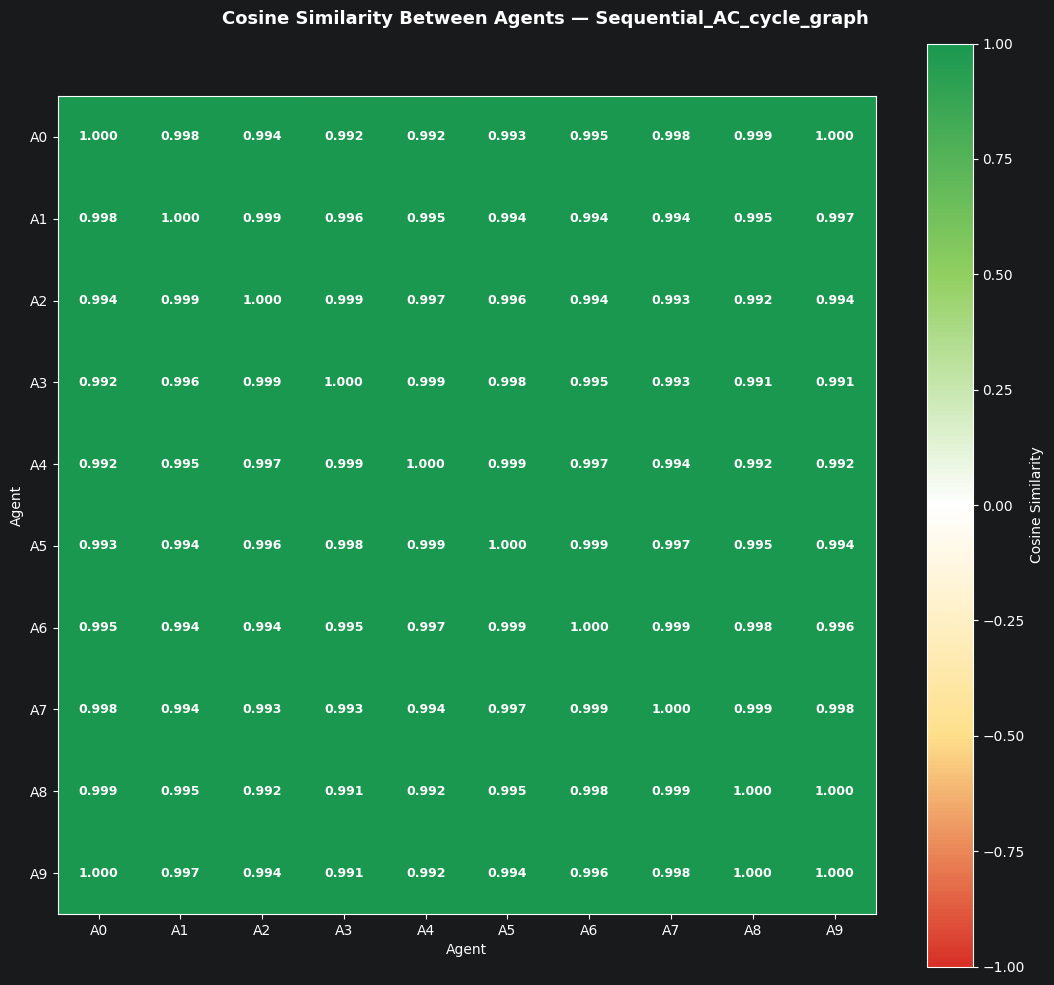

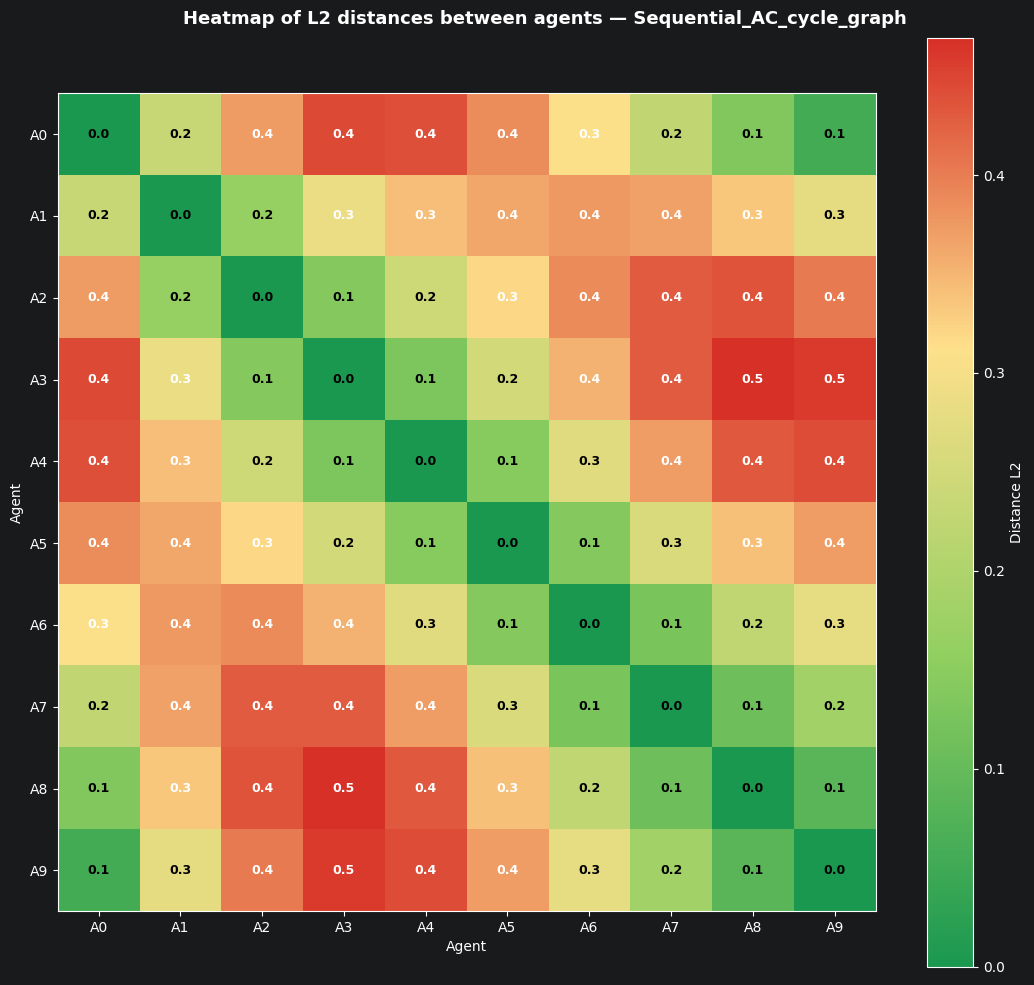

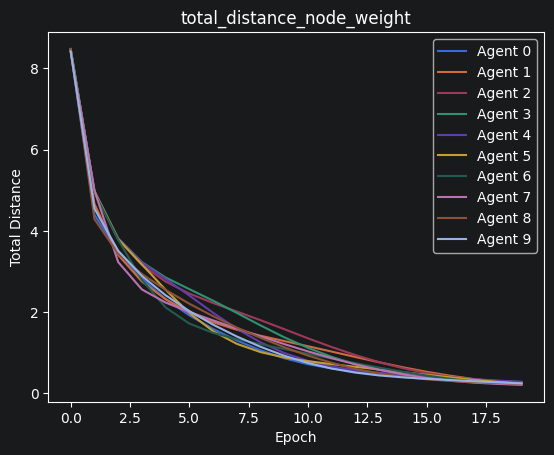

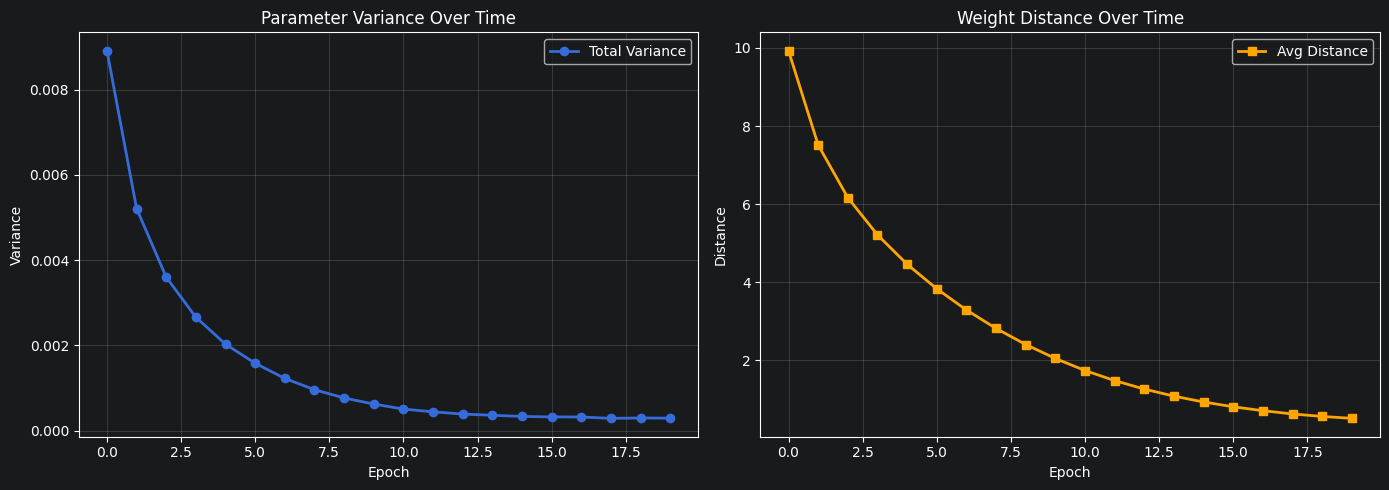


══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_cycle_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 20
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 94.614 MB
    Total messages    : 400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 17.20 ms
    Synchro totale    : 344.0 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 46.92%
  Val Loss  finale : 1.4607
  Temps total      : 843.70

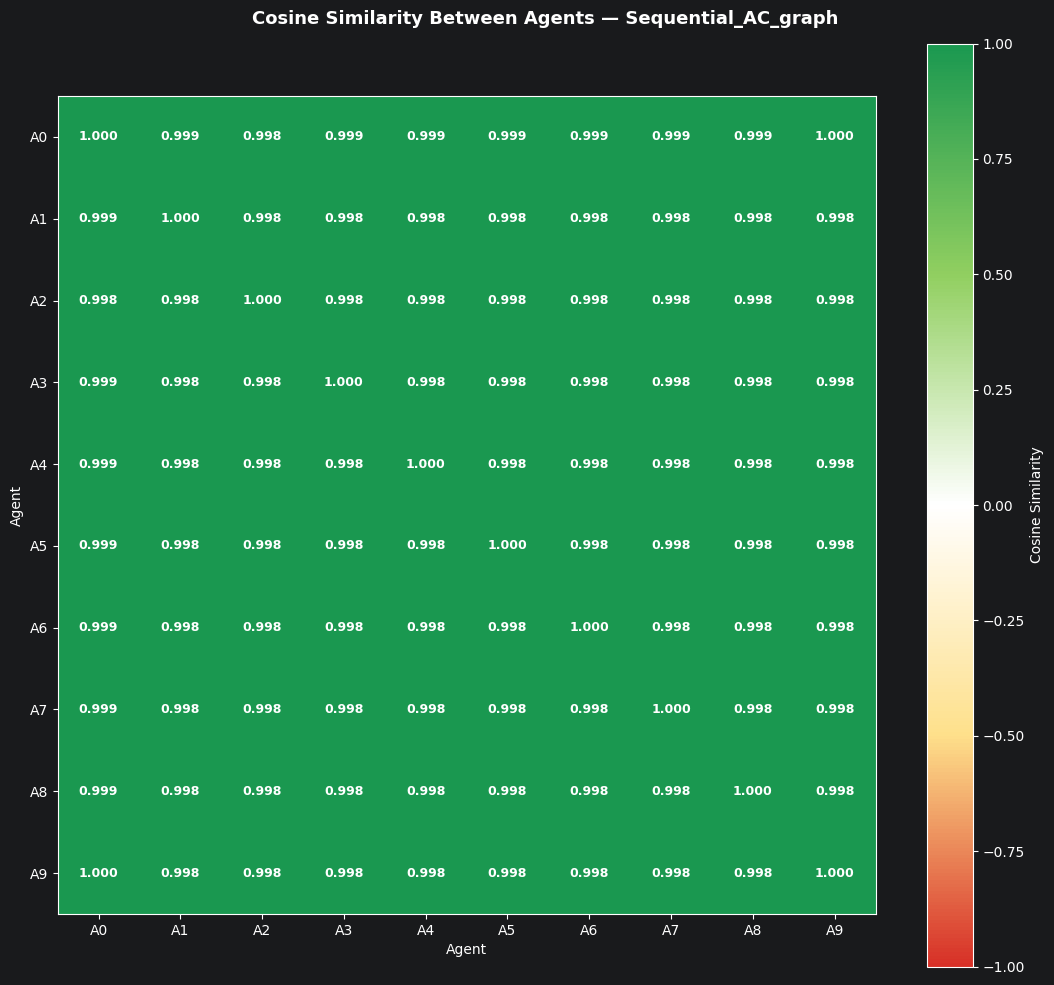

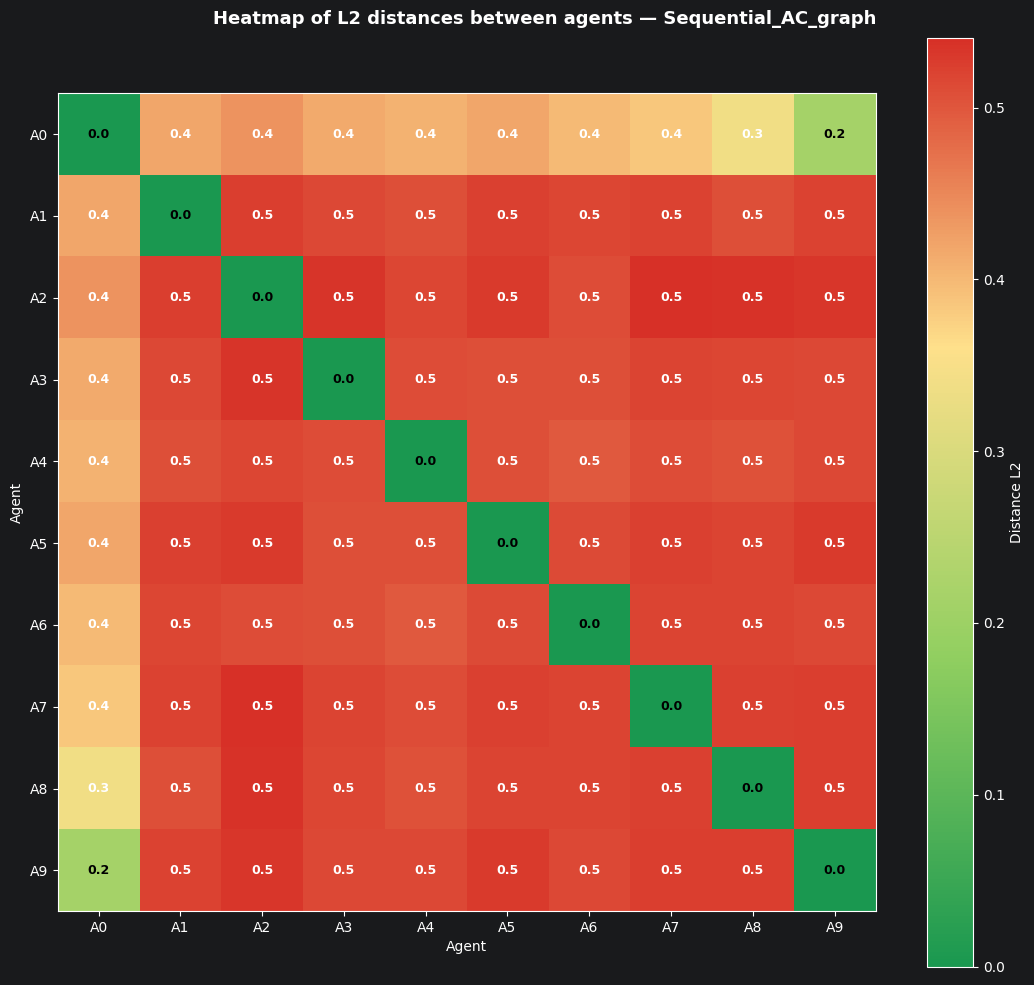

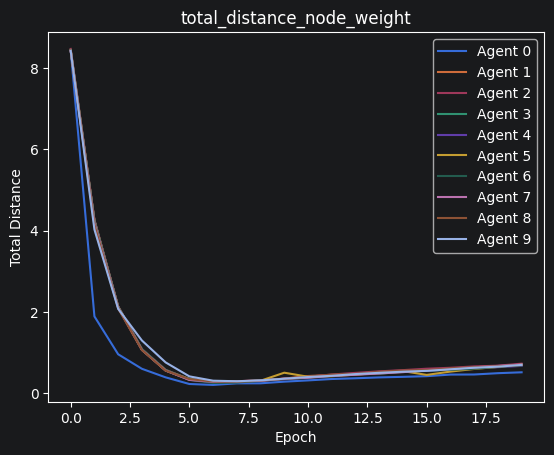

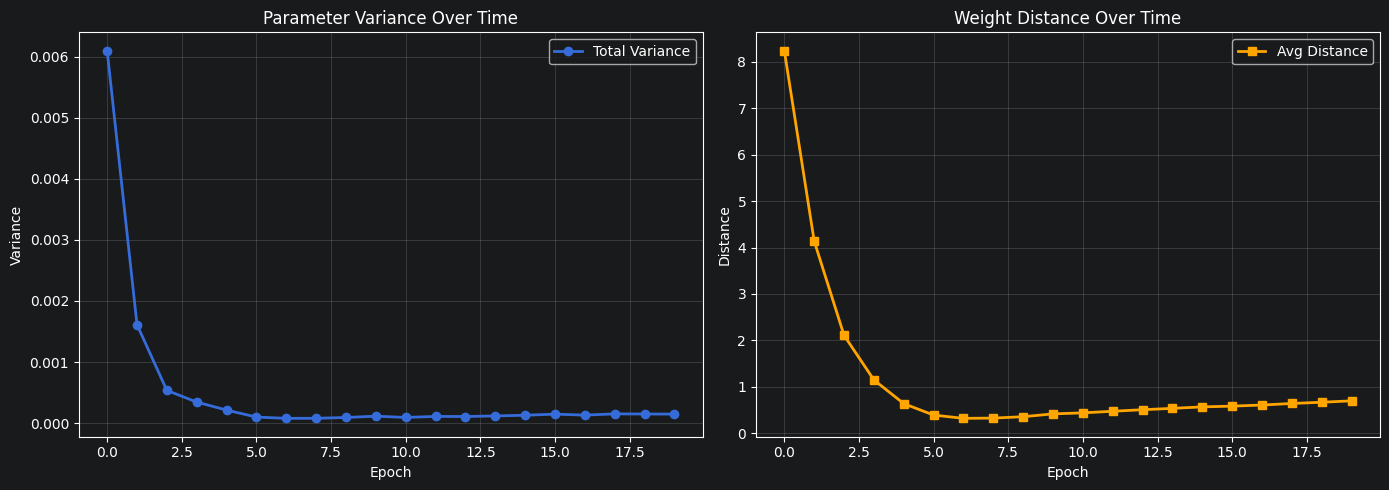


══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 20
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 85.152 MB
    Total messages    : 360
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 14.97 ms
    Synchro totale    : 299.5 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 32.53%
  Val Loss  finale : 1.8242
  Temps total      : 848.8

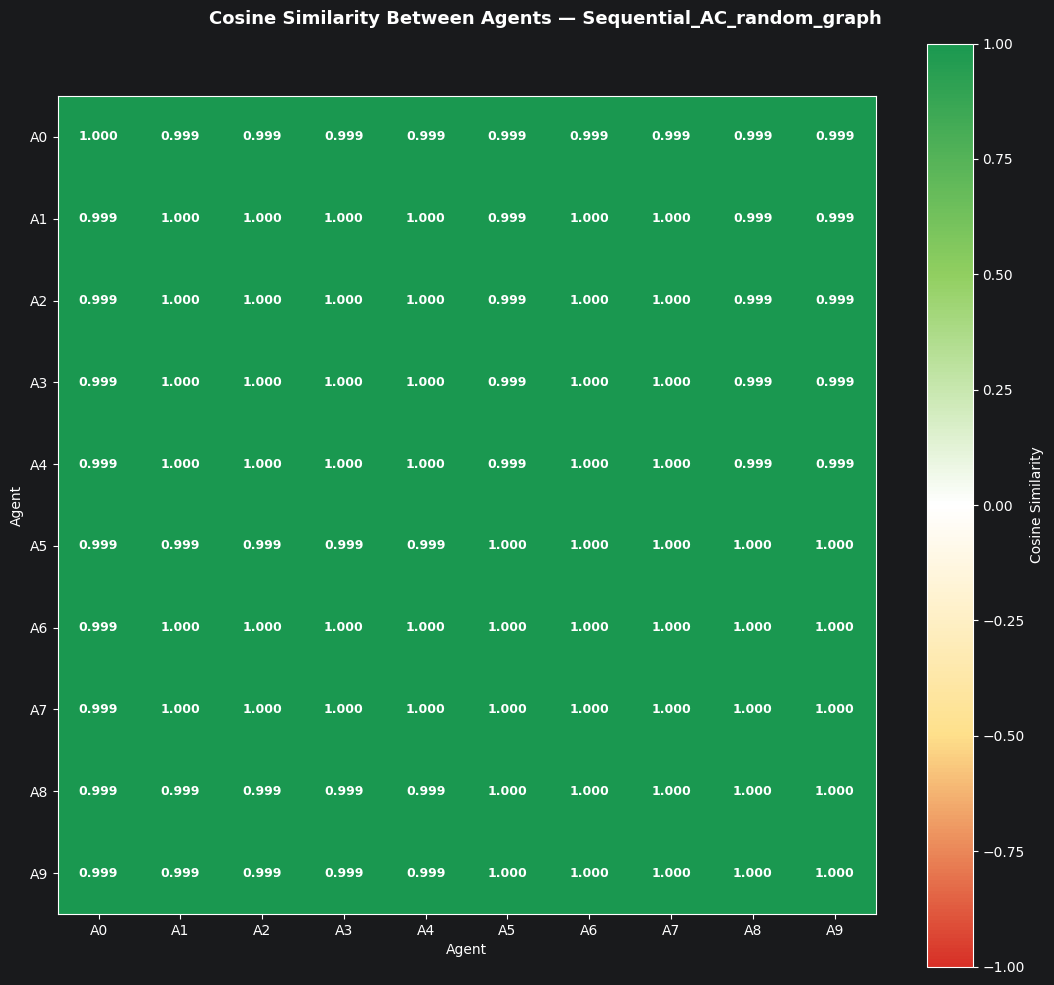

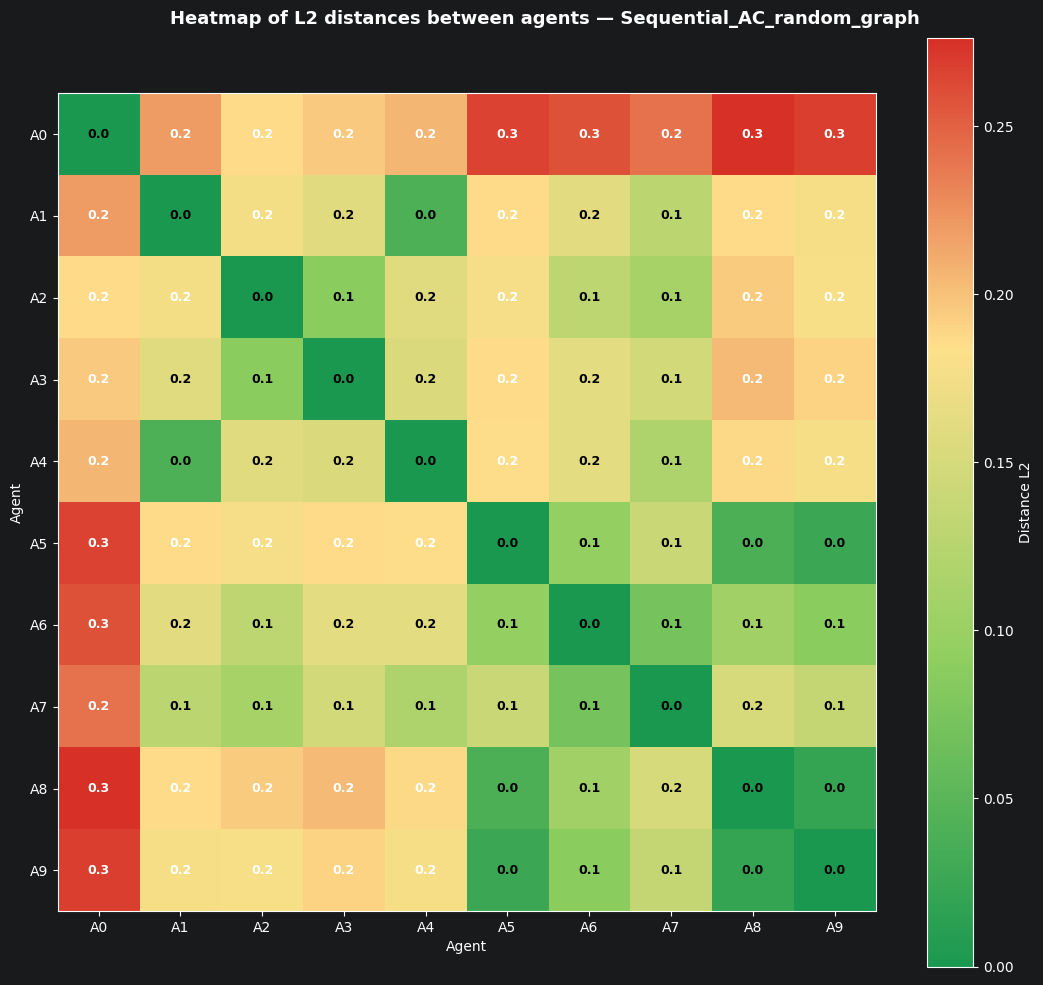

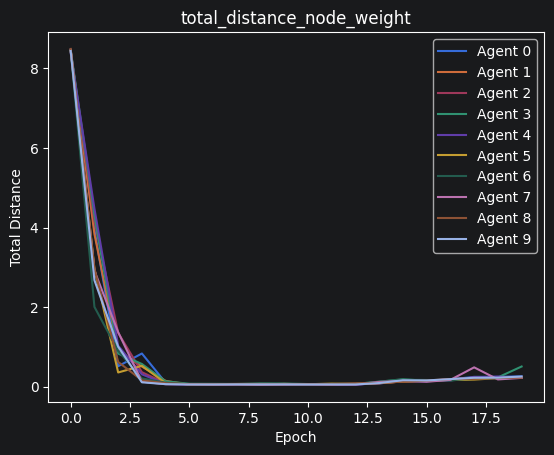

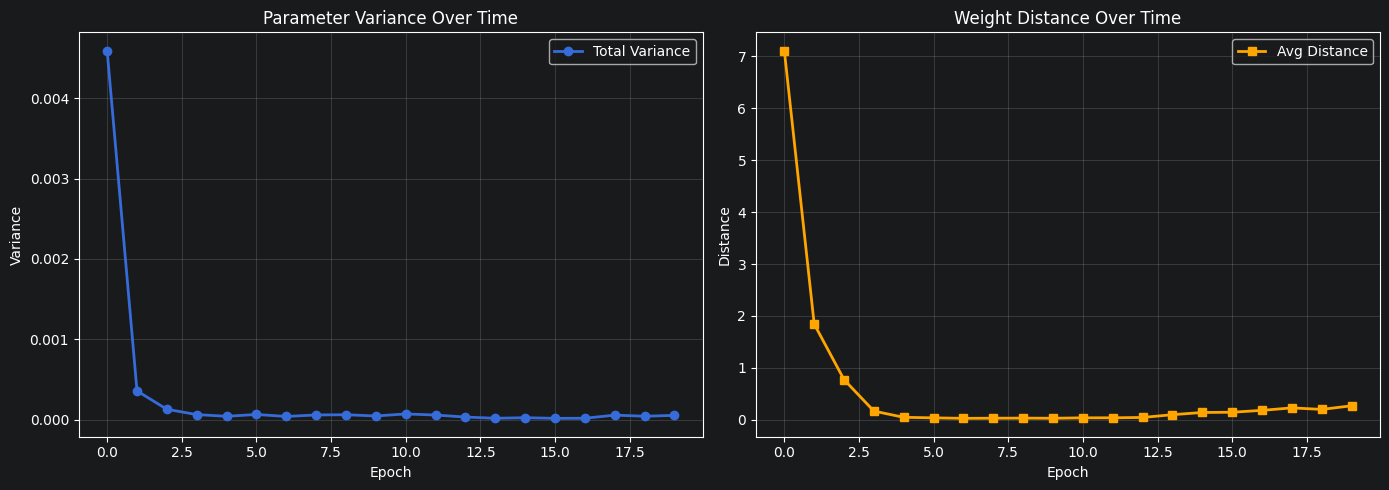


══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_random_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 20
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 198.216 MB
    Total messages    : 838
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 34.78 ms
    Synchro totale    : 695.6 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════



In [13]:
def Sequential_AC_fully_connected_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_cycle_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_star_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_random_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.random_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "Sequential_AC_connected_graph":    Sequential_AC_fully_connected_graph,
    "Sequential_AC_cycle_graph":        Sequential_AC_cycle_graph,
    "Sequential_AC_graph":              Sequential_AC_star_graph,
    "Sequential_AC_random_graph":       Sequential_AC_random_graph,
}

# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 20

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 10
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()
    result.comm_cost.summary()

In [ ]:
def Average_consensus_fully_connected_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_cycle_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_star_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_random_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.random_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_fully_connected_graph":
        Average_consensus_fully_connected_graph,

    "AC_cycle_graph":
        Average_consensus_cycle_graph,

    "AC_star_graph":
        Average_consensus_star_graph,

    "AC_random_graph":
        Average_consensus_random_graph,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()
    result.comm_cost.summary()